# Off-Diagonal Response Matrix (SNR Weighted)

This notebook creates multi-statistic heatmaps for the full 100-model response matrix.
Uses the **same** approach as `response_analysis_h5.ipynb` for computing F values.

**Weighting:** Uses **SNR weighting** = fractional signal × inverse variance:
$$\langle F \rangle_{\rm SNR} = \frac{\sum_i \left| \frac{H_i - D_i}{D_i} \right| \cdot (1/\sigma_{F,i}^2) \cdot F_i}{\sum_i \left| \frac{H_i - D_i}{D_i} \right| \cdot (1/\sigma_{F,i}^2)}$$

This downweights noisy bins while prioritizing where baryons matter most.

**Key insight:** The 100 models (10 mass bins × 10 radius bins) include:
- **Discrete (16 tiles):** Exclusive mass × radius combinations along the "diagonal"
- **Cumulative (16 models):** From M_min to M_max=10^15, from R=0 to α·R200  
- **Off-diagonal (68 models):** Extended ranges that span multiple bins

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from itertools import combinations
import scienceplots
import NG_stats_analysis as NGstats
plt.style.use(['science', 'notebook'])

## 1. Configuration Setup

In [2]:
# Constants
MASS_EDGES = [12.0, 12.5, 13.0, 13.5, 15.0]  # log10(M/[Msun/h])
RADIUS_EDGES = [0.0, 0.5, 1.0, 3.0, 5.0]     # R/R_200

# All 8 statistics to compute
STATISTICS = ['Pk', 'Cl', 'pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

# Redshift settings
Z_IDX = 23  # z_s ≈ 1.0
Z_VAL = 1.0

# All possible (M_lo, M_hi) and (R_in, R_out) combinations = 10×10 = 100
mass_bins = list(combinations(MASS_EDGES, 2))      # 10 mass bins
radius_bins = list(combinations(RADIUS_EDGES, 2))  # 10 radius shells

print(f"Total configurations: {len(mass_bins)} × {len(radius_bins)} = {len(mass_bins)*len(radius_bins)}")

Total configurations: 10 × 10 = 100


In [3]:
def get_model_name(M_lo, M_hi, R_in, R_out):
    """Generate model name from bin edges."""
    # Format mass values, removing '+' from exponent (1.00e+12 -> 1.00e12)
    M_lo_str = f"{10**M_lo:.2e}".replace('e+', 'e')
    M_hi_str = f"{10**M_hi:.2e}".replace('e+', 'e')
    return f"hydro_replace_Ml_{M_lo_str}_Mu_{M_hi_str}_Ri_{R_in}_Ro_{R_out}"

# Test
print(f"Example: {get_model_name(12.0, 12.5, 0.0, 0.5)}")

Example: hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_0.5


## 2. Load Statistics Using Same Approach as response_analysis_h5.ipynb

In [4]:
base_path = '/mnt/home/mlee1/ceph/hydro_replace_stats'

def load_model_stats(model_name):
    """Load ALL statistics for a model from HDF5."""
    file_path = f"{base_path}/{model_name}/stats.h5"
    try:
        with h5py.File(file_path, 'r') as f:
            data = {key: f[key][()] for key in f.keys()}
            attrs = dict(f.attrs)
        return data, attrs
    except Exception as e:
        return None, None

# Generate all 100 model names
ALL_MODELS = []
for M_lo, M_hi in mass_bins:
    for R_in, R_out in radius_bins:
        ALL_MODELS.append(get_model_name(M_lo, M_hi, R_in, R_out))

print(f"Total models to load: {len(ALL_MODELS)}")

# Load all model stats (same approach as response_analysis_h5.ipynb)
all_model_stats = {}
missing = []
for model_name in ALL_MODELS:
    data, _ = load_model_stats(model_name)
    if data is not None:
        all_model_stats[model_name] = data
    else:
        missing.append(model_name)

print(f"Loaded: {len(all_model_stats)} models")
print(f"Missing: {len(missing)} models")

# Load base models
base_stats = {
    'hydro': load_model_stats('hydro')[0], 
    'dmo': load_model_stats('dmo')[0]
}
print(f"Base models loaded: {list(base_stats.keys())}")

Total models to load: 100


Loaded: 100 models
Missing: 0 models
Base models loaded: ['hydro', 'dmo']


## 3. Compute F for All Statistics Using NGstats Framework

This uses `NGstats.compute_statistic_response()` - the **exact same approach** as `response_analysis_h5.ipynb`.

**NEW:** Uses **SNR weighting** (fractional signal × inverse variance) instead of fractional-signal-only weighting. This properly downweights noisy bins while still prioritizing where baryons matter most.

In [16]:
# Compute F for each statistic using the proper framework
# We treat ALL 100 models as "cumulative" type for compute_statistic_response
# (it doesn't matter for F computation - we just need the results dict)

all_results = {}

for stat_name in STATISTICS:
    print(f"Computing {stat_name}...")
    
    # Compute response using the unified framework
    # Pass all models as "cumulative" (name doesn't matter for F computation)
    results = NGstats.compute_statistic_response(
        cum_stats=all_model_stats,
        disc_stats={},  # Empty - we're putting everything in cum_stats
        base_stats=base_stats,
        CUM_MODELS=list(all_model_stats.keys()),
        DISC_MODELS=[],
        stat_name=stat_name,
        compute_F_func=NGstats.compute_F,
        mask_all_small=True if stat_name in ['pdf', 'peaks', 'minima', 'V0', 'V1', 'V2'] else False,
        threshold=0.03 if stat_name in ['pdf', 'peaks', 'minima', 'V0', 'V1', 'V2'] else 0.03,
        k_nyquist=64 if stat_name == 'Pk' else 5 if stat_name == 'minima' else 1e6
    )
    all_results[stat_name] = results

print(f"\n✓ Computed F for {len(all_results)} statistics")

Computing Pk...


Computing Cl...
Computing pdf...


/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: invalid value encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: invalid value encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: divide by zero encountered in divide
  F_raw = numerator / denom


Computing peaks...
Computing minima...


/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: divide by zero encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)


Computing V0...
Computing V1...
Computing V2...

✓ Computed F for 8 statistics


In [18]:
# SNR-weighted F averaging function (defined early so all sections can use it)
def compute_snr_weighted_F(results, model_name, z_idx):
    """
    Compute SNR-weighted average F.
    Weights = |(H-D)/D| × 1/σ_F² (fractional signal × inverse variance)
    
    This properly downweights noisy bins while still prioritizing where baryons matter.
    """
    
    
    
    
    
    
    
    
    # Get bin-wise F and F_err
    F_binwise = results['cum_F'].get(model_name, None)
    F_err_binwise = results['cum_F_err'].get(model_name, None)
    
    if F_binwise is None:
        return np.nan, np.nan
    
    # Select the redshift plane
    if z_idx >= F_binwise.shape[0]:
        return np.nan, np.nan
    
    F = F_binwise[z_idx]  # shape (n_bins,)
    F_err = F_err_binwise[z_idx] if F_err_binwise is not None else np.ones_like(F)
    
    # Get base statistics for fractional signal
    H = results['base_mean']['hydro'][z_idx]
    D = results['base_mean']['dmo'][z_idx]
    
    # Fractional signal: |(H-D)/D|
    with np.errstate(divide='ignore', invalid='ignore'):
        frac_signal = np.abs((H - D) / D)
        frac_signal = np.where(np.isfinite(frac_signal), frac_signal, 0)
    
    # Inverse variance weights (handle zeros/infinities)
    with np.errstate(divide='ignore', invalid='ignore'):
        inv_var = np.where((F_err > 0) & np.isfinite(F_err), 1.0 / (F_err**2), 0)
    
    # Combined weight: signal × inverse_variance
    weights = frac_signal * inv_var
    
    # Mask out invalid bins
    valid = np.isfinite(F) & np.isfinite(weights) & (weights > 0)
    
    if np.sum(valid) < 2:
        return np.nan, np.nan
    
    # Weighted mean
    weighted_F = np.sum(weights[valid] * F[valid]) / np.sum(weights[valid])
    
    # Uncertainty: 1/sqrt(sum(weights)) weighted by signal
    weighted_err = 1.0 / np.sqrt(np.sum(weights[valid]))
    
    return weighted_F, weighted_err


def get_F_value(results, model_name, z_idx, weighting='snr'):
    """
    Extract F value using various weighting schemes.
    
    Parameters
    ----------
    results : dict
        Results from compute_statistic_response()
    model_name : str
        Model name
    z_idx : int
        Redshift index
    weighting : str
        'snr' (default), 'frac_signal', 'signal', 'inverse_variance', or 'uniform'
    
    Returns
    -------
    F_val : float
        Integrated F value (NaN if not found)
    """
    # SNR weighting: combines fractional signal with inverse variance
    if weighting == 'snr':
        F_val, _ = compute_snr_weighted_F(results, model_name, z_idx)
        return F_val
    
    # Original fractional-signal weighting
    elif weighting == 'frac_signal':
        scores_key = 'cum_integrated_scores'
        if scores_key in results and model_name in results[scores_key]:
            return results[scores_key][model_name]['frac_signal_weighted_F'][z_idx]
    
    # Absolute signal weighting
    elif weighting == 'signal':
        scores_key = 'cum_integrated_scores'
        if scores_key in results and model_name in results[scores_key]:
            return results[scores_key][model_name]['signal_weighted_F'][z_idx]
    
    # Inverse variance weighting (without signal weighting)
    elif weighting == 'inverse_variance':
        if 'weighted_mean_cum_F' in results and model_name in results['weighted_mean_cum_F']:
            return results['weighted_mean_cum_F'][model_name][z_idx]
    
    # Uniform weighting
    elif weighting == 'uniform':
        mean_key = 'mean_cum_F'
        if mean_key in results and model_name in results[mean_key]:
            return results[mean_key][model_name][z_idx]
    
    return np.nan

# Test: Get F for one model and one statistic
test_model = get_model_name(12.0, 15.0, 0.0, 5.0)  # Cumulative: all masses, all radii
if test_model in all_model_stats:
    F_Cl = get_F_value(all_results['Cl'], test_model, Z_IDX, weighting='snr')
    F_Pk = get_F_value(all_results['Pk'], test_model, 0, weighting='snr')  # Pk uses snapshot index
    print(f"Test model: {test_model}")
    print(f"  F(Cl) at z_s=1.0 [SNR weighted]: {F_Cl:.3f}")
    print(f"  F(Pk) at z=0.0 [SNR weighted]: {F_Pk:.3f}")

Test model: hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0
  F(Cl) at z_s=1.0 [SNR weighted]: 0.923
  F(Pk) at z=0.0 [SNR weighted]: 0.904


## 4. Build F Matrix for All 100 Models × All 8 Statistics

In [19]:
# Build a dictionary: model_name -> {stat: F_value}
# Using SNR weighting (fractional signal × inverse variance)
F_all = {}

for model_name in ALL_MODELS:
    F_all[model_name] = {}
    for stat_name in STATISTICS:
        # Use z_idx=0 for Pk (3D power spectrum at z=0), z_idx=23 for WL stats (z_s=1.0)
        z_idx = 0 if stat_name == 'Pk' else Z_IDX
        F_val = get_F_value(all_results[stat_name], model_name, z_idx, weighting='snr')
        F_all[model_name][stat_name] = F_val

# Check coverage
n_valid = sum(1 for m in F_all if any(np.isfinite(F_all[m].get(s, np.nan)) for s in STATISTICS))
print(f"Models with at least one valid F (SNR weighted): {n_valid}/{len(ALL_MODELS)}")

Models with at least one valid F (SNR weighted): 100/100


## 5. Multi-Statistic Heatmap: Full 10×10 Grid

Layout:
- **Upper-left 4×4:** Discrete (exclusive) tiles
- **Middle band:** Extended (off-diagonal) tiles  
- **Lower-right 4×4:** Cumulative tiles

**Corner tile** (M=13.5-15, R=0-0.5) is both discrete AND cumulative - shown in both regions.

In [20]:
# Bin ordering: Discrete first (exclusive), then extended, then cumulative
# Mass in DECREASING order (high mass at top)

mass_bins_ordered = [
    # Discrete (exclusive) - HIGH mass first
    (13.5, 15.0),   # [M4] - Also cumulative (corner tile)
    (13.0, 13.5),   # [M3]
    (12.5, 13.0),   # [M2]
    (12.0, 12.5),   # [M1]
    # Cumulative (includes corner tile duplicated)
    (13.5, 15.0),   # Corner tile REPEATED
    (13.0, 15.0),   # M >= 10^13
    (12.5, 15.0),   # M >= 10^12.5
    (12.0, 15.0),   # M >= 10^12 (full)
]

radius_bins_ordered = [
    # Discrete (exclusive) - includes corner at R=0-0.5
    (0.0, 0.5),     # [R1] - Also cumulative (corner tile)
    (0.5, 1.0),     # [R2]
    (1.0, 3.0),     # [R3]
    (3.0, 5.0),     # [R4]
    # Cumulative (includes corner tile duplicated)
    (0.0, 0.5),     # Corner tile REPEATED
    (0.0, 1.0),     # R < 1 R200
    (0.0, 3.0),     # R < 3 R200
    (0.0, 5.0),     # R < 5 R200 (full)
]

print(f"Grid size: {len(mass_bins_ordered)} × {len(radius_bins_ordered)}")

Grid size: 8 × 8


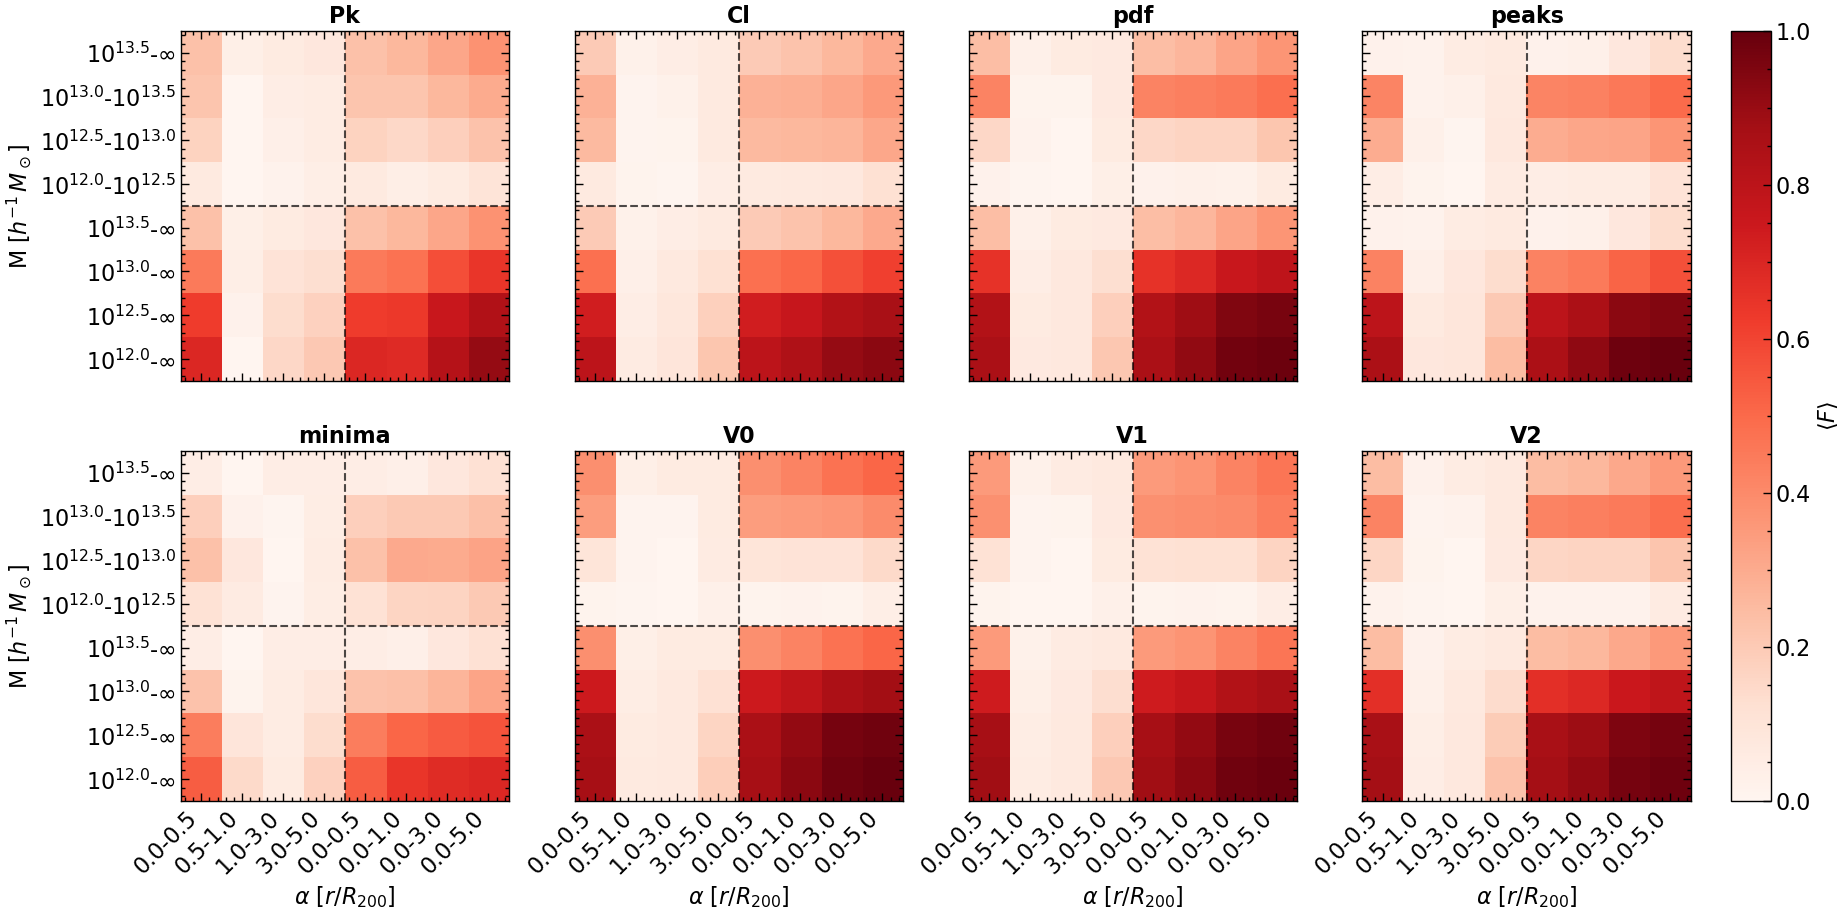

In [35]:
# Create the multi-statistic heatmap with shared axes
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)

# Labels - use infinity symbol for M_hi = 15
mass_labels = [f"$10^{{{M_lo:.1f}}}$-$\\infty$" if M_hi == 15.0 else f"$10^{{{M_lo:.1f}}}$-$10^{{{M_hi:.1f}}}$" 
               for M_lo, M_hi in mass_bins_ordered]
radius_labels = [f"{R_in}-{R_out}" for R_in, R_out in radius_bins_ordered]

# Store images for shared colorbar
images = []

for idx, (ax, stat) in enumerate(zip(axes.flatten(), STATISTICS)):
    row, col = idx // 4, idx % 4
    
    # Build F matrix
    F_matrix = np.full((len(mass_bins_ordered), len(radius_bins_ordered)), np.nan)
    
    for i, (M_lo, M_hi) in enumerate(mass_bins_ordered):
        for j, (R_in, R_out) in enumerate(radius_bins_ordered):
            model_name = get_model_name(M_lo, M_hi, R_in, R_out)
            if model_name in F_all:
                F_matrix[i, j] = F_all[model_name].get(stat, np.nan)
    
    # Plot heatmap
    im = ax.imshow(F_matrix, cmap='Reds', aspect='auto', origin='upper',
                   vmin=-0., vmax=1.0)
    images.append(im)
    
    # Set ticks (shared, so only need to set once effectively)
    ax.set_xticks(range(len(radius_bins_ordered)))
    ax.set_yticks(range(len(mass_bins_ordered)))
    
    # Only show x-axis labels on bottom row
    if row == 1:
        ax.set_xticklabels(radius_labels, rotation=45, ha='right')
        ax.set_xlabel(r'$\alpha$ [$r/R_{200}$]')
    
    # Only show y-axis labels on leftmost column
    if col == 0:
        ax.set_yticklabels(mass_labels, rotation=0)
        ax.set_ylabel(r'M [$h^{-1}\,M_\odot$]')
    
    ax.set_title(f'{stat}', fontweight='bold')
    
    # Region boundaries
    ax.axhline(3.5, color='k', lw=1.5, ls='--', alpha=0.7)
    ax.axvline(3.5, color='k', lw=1.5, ls='--', alpha=0.7)
    # ax.axhline(6.5, color='k', lw=1.5, ls='--', alpha=0.7)
    # ax.axvline(6.5, color='k', lw=1.5, ls='--', alpha=0.7)
    
    # Highlight repeated row (0 and 7: same M=13.5-15) and column (0 and 7: same R=0-0.5)
    # Row 0 = Row 7, Column 0 = Column 7
    n_cols = len(radius_bins_ordered)
    n_rows = len(mass_bins_ordered)
    
    # Highlight repeated rows (row 0 and row 7)
    # for row_idx in [0, 7]:
    #     rect = plt.Rectangle((-0.5, row_idx - 0.5), n_cols, 1,
    #                           fill=False, edgecolor='gold', lw=2.5)
    #     ax.add_patch(rect)
    
    # # Highlight repeated columns (col 0 and col 7)
    # for col_idx in [0, 7]:
    #     rect = plt.Rectangle((col_idx - 0.5, -0.5), 1, n_rows,
    #                           fill=False, edgecolor='gold', lw=2.5)

# Single shared colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.11, 0.02, 0.77])
cbar = fig.colorbar(images[0], cax=cbar_ax)
cbar.set_label(r'$\langle F \rangle$')

plt.savefig('figures/multi_stat_response_matrix_all8.pdf', dpi=200, bbox_inches='tight')
plt.show()

## Interactive Response Figure (AAS Journal Compatible)

This creates an interactive figure where:
1. **Main view**: Heatmap grid showing ⟨F⟩ for each (M, α) tile across all statistics
2. **On click**: Expands to show the full ν-dependent response curves (F_cum, ΔF_disc, ε)

Uses Bokeh to generate standalone HTML + JS that is AAS journal compatible.

In [ ]:
# Import Bokeh for interactive plotting
from bokeh.plotting import figure, show, output_file, save
from bokeh.layouts import column, row, gridplot, layout
from bokeh.models import (ColumnDataSource, HoverTool, TapTool, CustomJS, 
                          Div, LinearColorMapper, ColorBar, BasicTicker,
                          Panel, Tabs, Select, Slider, Range1d, Title, LabelSet)
from bokeh.palettes import RdYlBu11, Viridis256, Reds9
from bokeh.io import output_notebook, export_svgs
from bokeh.transform import linear_cmap

output_notebook()  # Show in notebook

print("Bokeh loaded successfully")

Loading BokehJS ...

Bokeh loaded successfully


In [45]:
def create_interactive_response_figure(all_results, F_all, stat_name='peaks', z_idx=23,
                                       output_html='figures/interactive_response.html'):
    """
    Create an interactive Bokeh figure with:
    - Main panel: Heatmap of ⟨F⟩(M, α)
    - Detail panels (update on tile click): F_cum(ν), ΔF_disc(ν), ε(ν)
    
    Parameters
    ----------
    all_results : dict
        Results dict from compute_statistic_response for each stat
    F_all : dict
        Pre-computed ⟨F⟩ values for all models
    stat_name : str
        Which statistic to show ('peaks', 'Cl', etc.)
    z_idx : int
        Redshift index
    output_html : str
        Output HTML file path
    """
    results = all_results[stat_name]
    
    # Model definitions
    mass_labels = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
    radius_labels = ['0.5', '1.0', '3.0', '5.0']
    disc_mass_lower = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
    disc_mass_upper = ['3.16e12', '1.00e13', '3.16e13', '1.00e15']
    disc_radius_inner = ['0.0', '0.5', '1.0', '3.0']
    disc_radius_outer = ['0.5', '1.0', '3.0', '5.0']
    
    mass_display = ['M > 10¹²', 'M > 10^12.5', 'M > 10¹³', 'M > 10^13.5']
    radius_display = ['α=0.5', 'α=1.0', 'α=3.0', 'α=5.0']
    
    # Extract data
    cum_F = results['cum_F']
    cum_F_err = results['cum_F_err']
    disc_F = results['disc_F']
    disc_F_err = results['disc_F_err']
    bins = results['bins']
    
    # Build heatmap data
    heatmap_data = {
        'x': [], 'y': [], 'F': [], 
        'mass_idx': [], 'radius_idx': [],
        'mass_label': [], 'radius_label': [],
        'model_name': []
    }
    
    for i, mass in enumerate(mass_labels):
        for j, radius in enumerate(radius_labels):
            model = f"hydro_replace_Ml_{mass}_Mu_1.00e15_Ri_0.0_Ro_{radius}"
            F_val = F_all.get(model, {}).get(stat_name, np.nan)
            
            heatmap_data['x'].append(j)
            heatmap_data['y'].append(3 - i)  # Flip so high mass is at top
            heatmap_data['F'].append(F_val if np.isfinite(F_val) else 0)
            heatmap_data['mass_idx'].append(i)
            heatmap_data['radius_idx'].append(j)
            heatmap_data['mass_label'].append(mass_display[i])
            heatmap_data['radius_label'].append(radius_display[j])
            heatmap_data['model_name'].append(model)
    
    heatmap_source = ColumnDataSource(heatmap_data)
    
    # Pre-compute all curve data for JavaScript callback
    # Store as JSON-serializable dict
    curve_data = {}
    for i, mass in enumerate(mass_labels):
        for j, radius in enumerate(radius_labels):
            key = f"{i}_{j}"
            model = f"hydro_replace_Ml_{mass}_Mu_1.00e15_Ri_0.0_Ro_{radius}"
            
            # Cumulative F
            if model in cum_F:
                F_cum = cum_F[model][z_idx].tolist()
                F_cum_err = cum_F_err[model][z_idx].tolist()
            else:
                F_cum = [0] * len(bins)
                F_cum_err = [0] * len(bins)
            
            # Discrete F (for matching radial shell)
            disc_model = f"hydro_replace_Ml_{disc_mass_lower[i]}_Mu_{disc_mass_upper[i]}_Ri_{disc_radius_inner[j]}_Ro_{disc_radius_outer[j]}"
            if disc_model in disc_F:
                F_disc = disc_F[disc_model][z_idx].tolist()
                F_disc_err = disc_F_err[disc_model][z_idx].tolist()
            else:
                F_disc = [0] * len(bins)
                F_disc_err = [0] * len(bins)
            
            # Residual (simplified - just F_cum for this tile)
            # In full version, sum all discrete tiles
            residual = [f - d for f, d in zip(F_cum, F_disc)]
            
            curve_data[key] = {
                'bins': bins.tolist(),
                'F_cum': F_cum,
                'F_cum_err': F_cum_err,
                'F_disc': F_disc,
                'F_disc_err': F_disc_err,
                'residual': residual,
                'mass': mass_display[i],
                'radius': radius_display[j]
            }
    
    # Create heatmap figure
    color_mapper = LinearColorMapper(palette=list(reversed(RdYlBu11)), low=0, high=1)
    
    heatmap = figure(width=400, height=400, 
                     title=f'{stat_name.upper()} Response ⟨F⟩ - Click tile for details',
                     x_range=(-0.5, 3.5), y_range=(-0.5, 3.5),
                     tools='tap,reset', toolbar_location='above')
    
    heatmap.rect(x='x', y='y', width=0.95, height=0.95, source=heatmap_source,
                 fill_color=linear_cmap('F', palette=list(reversed(RdYlBu11)), low=0, high=1),
                 line_color='white', line_width=2)
    
    # Add text annotations
    from bokeh.models import LabelSet
    labels = LabelSet(x='x', y='y', text='F', source=heatmap_source,
                      text_align='center', text_baseline='middle',
                      text_font_size='12pt', text_color='black')
    # Format F values
    heatmap_source.data['F_text'] = [f'{f:.2f}' for f in heatmap_source.data['F']]
    labels = LabelSet(x='x', y='y', text='F_text', source=heatmap_source,
                      text_align='center', text_baseline='middle',
                      text_font_size='11pt', text_color='black')
    heatmap.add_layout(labels)
    
    # Axis labels
    heatmap.xaxis.ticker = [0, 1, 2, 3]
    heatmap.xaxis.major_label_overrides = {0: 'α=0.5', 1: 'α=1.0', 2: 'α=3.0', 3: 'α=5.0'}
    heatmap.yaxis.ticker = [0, 1, 2, 3]
    heatmap.yaxis.major_label_overrides = {0: '10¹²', 1: '10^12.5', 2: '10¹³', 3: '10^13.5'}
    heatmap.xaxis.axis_label = 'Radius factor α'
    heatmap.yaxis.axis_label = 'M_min [M☉/h]'
    
    # Colorbar
    color_bar = ColorBar(color_mapper=color_mapper, ticker=BasicTicker(),
                         label_standoff=12, border_line_color=None, location=(0, 0),
                         title='⟨F⟩')
    heatmap.add_layout(color_bar, 'right')
    
    # Hover tool
    hover = HoverTool(tooltips=[
        ('Mass', '@mass_label'),
        ('Radius', '@radius_label'),
        ('⟨F⟩', '@F{0.3f}')
    ])
    heatmap.add_tools(hover)
    
    # Create detail line plots (initially empty, updated by callback)
    # We'll use 3 figures: F_cum, F_disc, residual
    
    # Initialize with first tile's data
    init_key = "0_0"
    init_data = curve_data[init_key]
    
    line_source = ColumnDataSource(data={
        'x': init_data['bins'],
        'F_cum': init_data['F_cum'],
        'F_disc': init_data['F_disc'],
        'residual': init_data['residual']
    })
    
    # Figure 1: Cumulative F
    p_cum = figure(width=350, height=250, title='Cumulative F',
                   x_axis_label='ν (S/N)', y_axis_label='F_cum',
                   y_range=(-0.3, 1.3))
    p_cum.line('x', 'F_cum', source=line_source, line_width=2, color='navy')
    p_cum.line([bins.min(), bins.max()], [0, 0], line_dash='dashed', color='gray')
    p_cum.line([bins.min(), bins.max()], [1, 1], line_dash='dashed', color='gray')
    
    # Figure 2: Discrete ΔF
    p_disc = figure(width=350, height=250, title='Discrete ΔF',
                    x_axis_label='ν (S/N)', y_axis_label='ΔF_disc',
                    y_range=(-0.3, 1.3))
    p_disc.line('x', 'F_disc', source=line_source, line_width=2, color='darkgreen')
    p_disc.line([bins.min(), bins.max()], [0, 0], line_dash='dashed', color='gray')
    
    # Figure 3: Residual ε
    p_res = figure(width=350, height=250, title='Residual ε = F_cum - ΔF_disc',
                   x_axis_label='ν (S/N)', y_axis_label='ε',
                   y_range=(-0.4, 0.4))
    p_res.line('x', 'residual', source=line_source, line_width=2, color='darkred')
    p_res.line([bins.min(), bins.max()], [0, 0], line_dash='dashed', color='gray')
    
    # Info div (shows selected tile info)
    info_div = Div(text=f"<b>Selected:</b> {init_data['mass']}, {init_data['radius']}", 
                   width=350, height=30)
    
    # JavaScript callback for tap (click) on heatmap
    callback = CustomJS(args=dict(source=line_source, 
                                   heatmap_source=heatmap_source,
                                   curve_data=curve_data,
                                   info_div=info_div), code="""
        const indices = heatmap_source.selected.indices;
        if (indices.length > 0) {
            const idx = indices[0];
            const mass_idx = heatmap_source.data['mass_idx'][idx];
            const radius_idx = heatmap_source.data['radius_idx'][idx];
            const key = mass_idx + '_' + radius_idx;
            
            if (curve_data[key]) {
                const data = curve_data[key];
                source.data['x'] = data['bins'];
                source.data['F_cum'] = data['F_cum'];
                source.data['F_disc'] = data['F_disc'];
                source.data['residual'] = data['residual'];
                source.change.emit();
                
                info_div.text = '<b>Selected:</b> ' + data['mass'] + ', ' + data['radius'];
            }
        }
    """)
    
    heatmap_source.selected.js_on_change('indices', callback)
    
    # Layout
    detail_col = column(info_div, p_cum, p_disc, p_res)
    full_layout = row(heatmap, detail_col)
    
    # Save to HTML
    output_file(output_html, title=f"Interactive {stat_name} Response")
    save(full_layout)
    print(f"Saved interactive figure to {output_html}")
    
    # Also show in notebook
    show(full_layout)
    
    return full_layout

In [49]:
# Create interactive figure for peaks
layout = create_interactive_response_figure(
    all_results, F_all, 
    stat_name='peaks', 
    z_idx=Z_IDX,
    output_html='figures/interactive_peaks_response.html'
)

Saved interactive figure to figures/interactive_peaks_response.html


RuntimeError: Models must be owned by only a single document, figure(id='p1175', ...) is already in a doc

In [50]:
def create_full_interactive_response(all_results, F_all, statistics=['peaks', 'Cl', 'Pk'],
                                     z_idx=23, output_html='figures/interactive_response_full.html'):
    """
    Enhanced interactive figure matching the 4×4 plot_combined_response layout.
    
    Features:
    - Tabs for each statistic
    - Heatmap overview showing all (M, α) tiles
    - Click on column → shows all 4 rows (ratio, F_cum, ΔF_disc, ε) for that α
    - All 4 mass thresholds shown as colored lines
    """
    from bokeh.models import TabPanel, Tabs
    from bokeh.palettes import Viridis4
    
    colors = Viridis4
    
    tabs = []
    
    for stat_name in statistics:
        results = all_results[stat_name]
        
        mass_labels = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
        radius_labels = ['0.5', '1.0', '3.0', '5.0']
        disc_mass_lower = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
        disc_mass_upper = ['3.16e12', '1.00e13', '3.16e13', '1.00e15']
        disc_radius_inner = ['0.0', '0.5', '1.0', '3.0']
        disc_radius_outer = ['0.5', '1.0', '3.0', '5.0']
        
        mass_display = ['M>10¹²', 'M>10^12.5', 'M>10¹³', 'M>10^13.5']
        
        cum_F = results['cum_F']
        cum_F_err = results['cum_F_err']
        disc_F = results['disc_F']
        disc_F_err = results['disc_F_err']
        base_mean = results['base_mean']
        bins = results['bins']
        
        # X-axis config
        if stat_name == 'Pk':
            x_axis_type = 'log'
            x_range = (0.1, 63)
        elif stat_name == 'Cl':
            x_axis_type = 'log'
            x_range = (1e3, 3e5)
        else:
            x_axis_type = 'linear'
            x_range = (-4, 8)
        
        # Build heatmap data
        heatmap_data = {'x': [], 'y': [], 'F': [], 'F_text': [], 
                        'radius_idx': [], 'radius_label': []}
        for i, mass in enumerate(mass_labels):
            for j, radius in enumerate(radius_labels):
                model = f"hydro_replace_Ml_{mass}_Mu_1.00e15_Ri_0.0_Ro_{radius}"
                F_val = F_all.get(model, {}).get(stat_name, np.nan)
                F_val = F_val if np.isfinite(F_val) else 0
                heatmap_data['x'].append(j)
                heatmap_data['y'].append(3 - i)
                heatmap_data['F'].append(F_val)
                heatmap_data['F_text'].append(f'{F_val:.2f}')
                heatmap_data['radius_idx'].append(j)
                heatmap_data['radius_label'].append(f'α={radius}')
        
        heatmap_source = ColumnDataSource(heatmap_data)
        
        # Pre-compute curves for each column (radius)
        # For each column, we show all 4 mass thresholds
        curve_data_by_col = {}
        for j, radius in enumerate(radius_labels):
            col_data = {
                'bins': bins.tolist(),
                'radius': radius
            }
            
            # For each mass threshold
            for k, mass in enumerate(mass_labels):
                cum_model = f"hydro_replace_Ml_{mass}_Mu_1.00e15_Ri_0.0_Ro_{radius}"
                disc_model = f"hydro_replace_Ml_{disc_mass_lower[k]}_Mu_{disc_mass_upper[k]}_Ri_{disc_radius_inner[j]}_Ro_{disc_radius_outer[j]}"
                
                # Cumulative F
                if cum_model in cum_F:
                    col_data[f'F_cum_{k}'] = cum_F[cum_model][z_idx].tolist()
                else:
                    col_data[f'F_cum_{k}'] = [np.nan] * len(bins)
                
                # Discrete F
                if disc_model in disc_F:
                    col_data[f'F_disc_{k}'] = disc_F[disc_model][z_idx].tolist()
                else:
                    col_data[f'F_disc_{k}'] = [np.nan] * len(bins)
                
                # Ratio S/S_dmo
                if cum_model in results['cum_mean']:
                    ratio = (results['cum_mean'][cum_model][z_idx] / 
                             base_mean['dmo'][z_idx])
                    col_data[f'ratio_{k}'] = ratio.tolist()
                else:
                    col_data[f'ratio_{k}'] = [np.nan] * len(bins)
            
            # Hydro/DMO ratio (reference)
            col_data['ratio_hydro'] = (base_mean['hydro'][z_idx] / 
                                       base_mean['dmo'][z_idx]).tolist()
            
            curve_data_by_col[str(j)] = col_data
        
        # Initialize line sources for column 0
        init_col = curve_data_by_col['0']
        
        # Sources for each mass threshold (4 lines per plot)
        line_sources = []
        for k in range(4):
            line_sources.append(ColumnDataSource(data={
                'x': init_col['bins'],
                'F_cum': init_col[f'F_cum_{k}'],
                'F_disc': init_col[f'F_disc_{k}'],
                'ratio': init_col[f'ratio_{k}']
            }))
        
        hydro_source = ColumnDataSource(data={
            'x': init_col['bins'],
            'ratio_hydro': init_col['ratio_hydro']
        })
        
        # Create heatmap
        color_mapper = LinearColorMapper(palette=list(reversed(RdYlBu11)), low=0, high=1)
        heatmap = figure(width=300, height=300, title=f'Click column for details',
                         x_range=(-0.5, 3.5), y_range=(-0.5, 3.5),
                         tools='tap,reset')
        heatmap.rect(x='x', y='y', width=0.95, height=0.95, source=heatmap_source,
                     fill_color=linear_cmap('F', palette=list(reversed(RdYlBu11)), low=0, high=1),
                     line_color='white', line_width=2)
        
        labels = LabelSet(x='x', y='y', text='F_text', source=heatmap_source,
                          text_align='center', text_baseline='middle',
                          text_font_size='10pt', text_color='black')
        heatmap.add_layout(labels)
        
        heatmap.xaxis.ticker = [0, 1, 2, 3]
        heatmap.xaxis.major_label_overrides = {0: 'α=0.5', 1: 'α=1.0', 2: 'α=3.0', 3: 'α=5.0'}
        heatmap.yaxis.ticker = [0, 1, 2, 3]
        heatmap.yaxis.major_label_overrides = {0: '10¹²', 1: '10^12.5', 2: '10¹³', 3: '10^13.5'}
        
        # Create detail plots (one column showing all 4 rows)
        p_ratio = figure(width=400, height=200, title='S / S_DMO',
                         x_axis_type=x_axis_type, y_range=(0.5, 1.5))
        p_cum = figure(width=400, height=200, title='F_cum',
                       x_axis_type=x_axis_type, y_range=(-0.3, 1.3),
                       x_range=p_ratio.x_range)
        p_disc = figure(width=400, height=200, title='ΔF_disc',
                        x_axis_type=x_axis_type, y_range=(-0.5, 1.0),
                        x_range=p_ratio.x_range)
        p_res = figure(width=400, height=200, title='ε (residual)',
                       x_axis_type=x_axis_type, y_range=(-0.4, 0.4),
                       x_range=p_ratio.x_range)
        
        # Add lines for each mass threshold
        for k in range(4):
            p_ratio.line('x', 'ratio', source=line_sources[k], 
                        line_width=2, color=colors[k], legend_label=mass_display[k])
            p_cum.line('x', 'F_cum', source=line_sources[k], 
                      line_width=2, color=colors[k])
            p_disc.line('x', 'F_disc', source=line_sources[k], 
                       line_width=2, color=colors[k])
        
        # Hydro reference line
        p_ratio.line('x', 'ratio_hydro', source=hydro_source, 
                    line_width=2, line_dash='dashed', color='black', legend_label='Hydro')
        
        # Reference lines
        for p in [p_cum, p_disc, p_res]:
            p.line(x_range, [0, 0], line_dash='dashed', color='gray')
        p_cum.line(x_range, [1, 1], line_dash='dashed', color='gray')
        p_ratio.line(x_range, [1, 1], line_dash='dashed', color='gray')
        
        p_ratio.legend.location = 'bottom_right'
        p_ratio.legend.label_text_font_size = '8pt'
        
        info_div = Div(text="<b>Column: α=0.5</b>", width=400, height=25)
        
        # JavaScript callback
        callback = CustomJS(args=dict(
            heatmap_source=heatmap_source,
            line_sources=line_sources,
            hydro_source=hydro_source,
            curve_data=curve_data_by_col,
            info_div=info_div
        ), code="""
            const indices = heatmap_source.selected.indices;
            if (indices.length > 0) {
                const idx = indices[0];
                const col = heatmap_source.data['radius_idx'][idx];
                const col_key = String(col);
                
                if (curve_data[col_key]) {
                    const data = curve_data[col_key];
                    
                    // Update each mass threshold line
                    for (let k = 0; k < 4; k++) {
                        line_sources[k].data['x'] = data['bins'];
                        line_sources[k].data['F_cum'] = data['F_cum_' + k];
                        line_sources[k].data['F_disc'] = data['F_disc_' + k];
                        line_sources[k].data['ratio'] = data['ratio_' + k];
                        line_sources[k].change.emit();
                    }
                    
                    hydro_source.data['x'] = data['bins'];
                    hydro_source.data['ratio_hydro'] = data['ratio_hydro'];
                    hydro_source.change.emit();
                    
                    info_div.text = '<b>Column: α=' + data['radius'] + '</b>';
                }
            }
        """)
        
        heatmap_source.selected.js_on_change('indices', callback)
        
        # Layout for this statistic
        detail_col = column(info_div, p_ratio, p_cum, p_disc, p_res)
        stat_layout = row(heatmap, detail_col)
        
        tabs.append(TabPanel(child=stat_layout, title=stat_name.upper()))
    
    # Combine all statistics in tabs
    full_layout = Tabs(tabs=tabs)
    
    output_file(output_html, title="Interactive Response Figures")
    save(full_layout)
    print(f"Saved to {output_html}")
    
    show(full_layout)
    return full_layout

In [51]:
# Create full interactive figure with tabs for multiple statistics
layout = create_full_interactive_response(
    all_results, F_all,
    statistics=['peaks', 'Cl', 'minima', 'V0'],
    z_idx=Z_IDX,
    output_html='figures/interactive_response_full.html'
)

/tmp/ipykernel_580186/1403363538.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = (results['cum_mean'][cum_model][z_idx] /
/tmp/ipykernel_580186/1403363538.py:101: RuntimeWarning: invalid value encountered in divide
  col_data['ratio_hydro'] = (base_mean['hydro'][z_idx] /


NameError: name 'LabelSet' is not defined

### AAS Journal Submission

To submit this interactive figure to AAS journals:

1. **Package the HTML file**:
   ```bash
   cd figures/
   zip interactive_response.zip interactive_response_full.html
   ```

2. **Create static PDF version** (for print):
   Use the matplotlib version (`multi_stat_response_matrix_all8.pdf`) as the static figure.

3. **LaTeX usage**:
   ```latex
   \begin{figure}
   \begin{interactive}{js}{interactive_response.zip}
   \includegraphics[width=\textwidth]{multi_stat_response_matrix_all8.pdf}
   \end{interactive}
   \caption{Response heatmap showing $\langle F \rangle$ for each (M, $\alpha$) tile. 
   \textbf{Interactive version}: Click on any tile to see the full $\nu$-dependent 
   response curves ($F_{\rm cum}$, $\Delta F_{\rm disc}$, $\epsilon$).}
   \end{figure}
   ```

The interactive version allows readers to:
- Click any heatmap tile to drill down into the ν-dependent response
- See all 4 mass thresholds overlaid with distinct colors  
- Compare cumulative, discrete, and residual contributions
- Switch between statistics (Peaks, Cl, etc.) using tabs

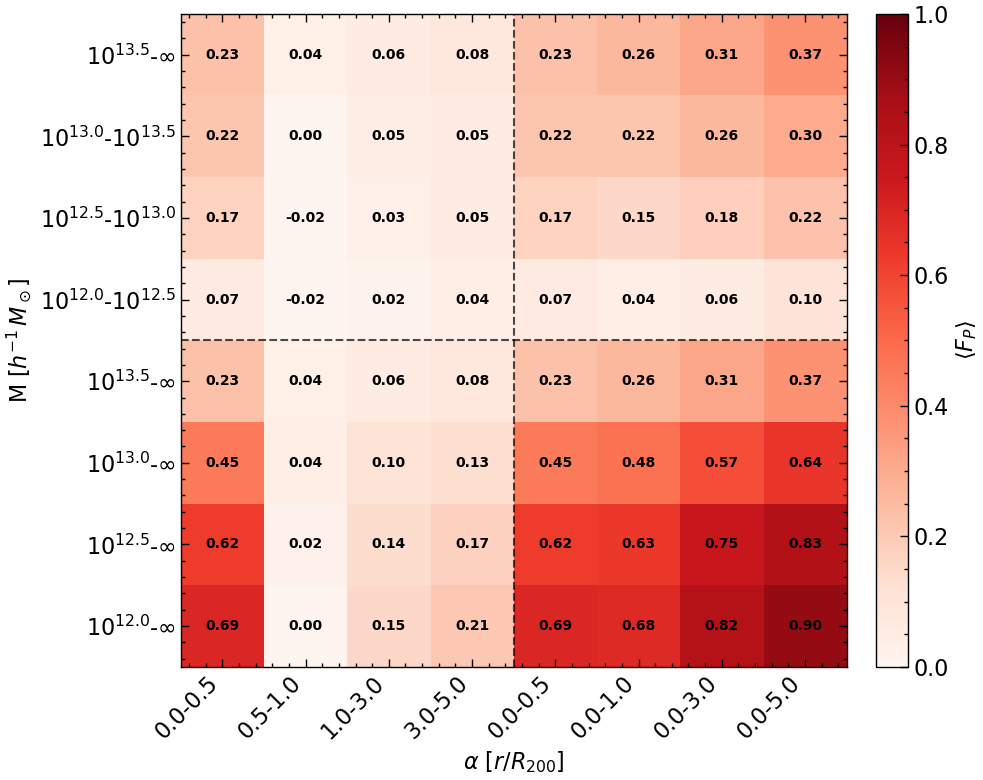

In [24]:
# Reload the module to pick up the new function
import importlib
import NG_stats_analysis as NGstats
importlib.reload(NGstats)

# Plot unified 8×8 heatmap for Pk using F_all dictionary (pre-computed SNR-weighted F values)
fig, ax = NGstats.plot_unified_stat_heatmap_from_F_all(
    F_all,                   # Use F_all dict directly (model_name -> {stat: F_value})
    stat_name='Pk', 
    cmap='Reds',
    vmin=0.0, 
    vmax=1.0,
    savename='figures/Pk_unified_heatmap_z0.pdf',
    show_region_boundaries=True,
    show_annotations=True,
    figsize=(10, 8)
)

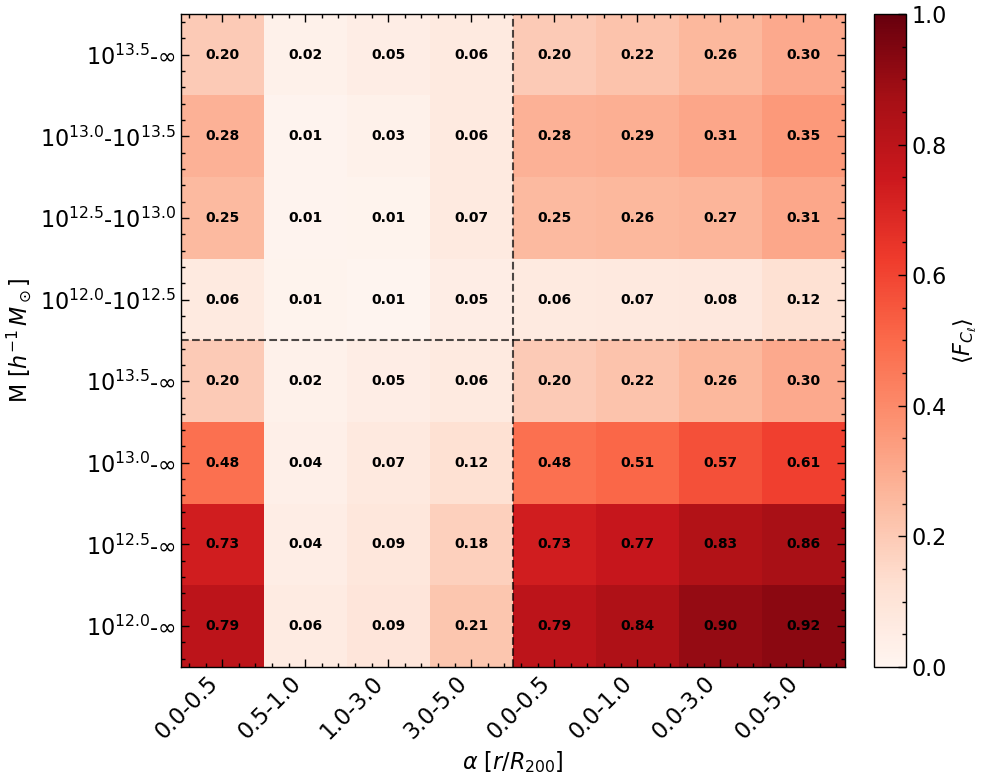

In [28]:
# Reload the module to pick up the new function
import importlib
import NG_stats_analysis as NGstats
importlib.reload(NGstats)

# Plot unified 8×8 heatmap for Pk using F_all dictionary (pre-computed SNR-weighted F values)
fig, ax = NGstats.plot_unified_stat_heatmap_from_F_all(
    F_all,                   # Use F_all dict directly (model_name -> {stat: F_value})
    stat_name='Cl', 
    cmap='Reds',
    vmin=0.0, 
    vmax=1.0,
    savename='figures/Cl_unified_heatmap_z1.pdf',
    show_region_boundaries=True,
    show_annotations=True,
    figsize=(10, 8)
)

/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:2170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  val = F_matrix_cum[i, j]


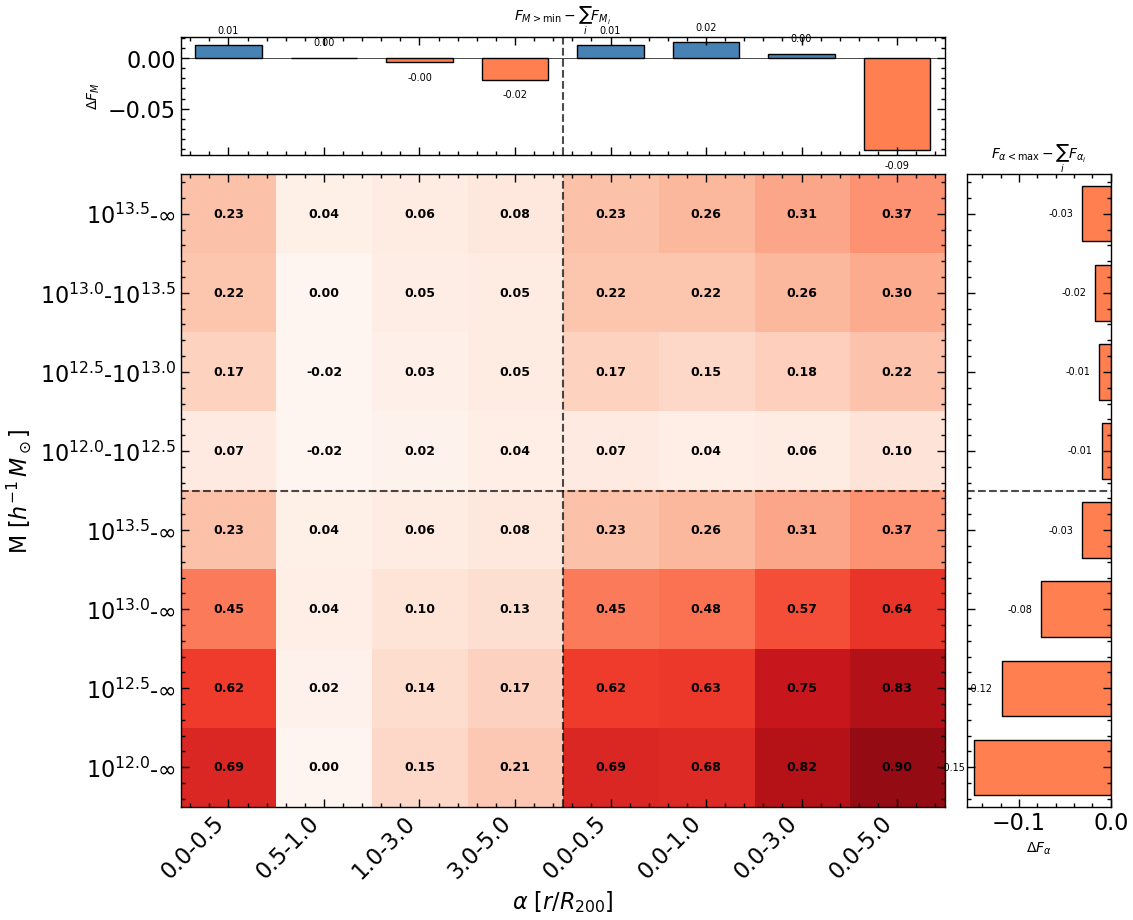

In [26]:
# Reload the module and test heatmap with marginal difference plots
import importlib
import NG_stats_analysis as NGstats
importlib.reload(NGstats)

# Plot unified heatmap with marginal nonlinearity plots
fig, axes = NGstats.plot_unified_stat_heatmap_with_margins(
    F_all,
    stat_name='Pk', 
    cmap='Reds',
    vmin=0.0, 
    vmax=1.0,
    savename='figures/Pk_unified_heatmap_with_margins.pdf',
    show_region_boundaries=True,
    show_annotations=True,
    figsize=(12, 10)
)

In [14]:
def compute_radial_fingerprints(F_all, statistics):
    """
    Compute the contribution from each radial shell, integrated over all masses.
    
    Uses "cumulative in M, exclusive in alpha" models:
      - M_lo=12.0, M_hi=15.0 (all masses)
      - Exclusive radius bins: [0, 0.5], [0.5, 1], [1, 3], [3, 5]
    
    Returns
    -------
    fingerprints : dict
        {stat_name: np.array([F_shell1, F_shell2, F_shell3, F_shell4])}
    """
    # Define the radial shells (exclusive)
    radius_shells = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
    
    fingerprints = {}
    
    for stat_name in statistics:
        shell_contributions = []
        
        for R_in, R_out in radius_shells:
            # Cumulative in mass (all masses), exclusive in this radius shell
            model_name = get_model_name(12.0, 15.0, R_in, R_out)
            
            if model_name in F_all and stat_name in F_all[model_name]:
                F_val = F_all[model_name][stat_name]
                if np.isfinite(F_val):
                    shell_contributions.append(F_val)
                else:
                    shell_contributions.append(0.0)
            else:
                shell_contributions.append(0.0)
        
        fingerprints[stat_name] = np.array(shell_contributions)
    
    return fingerprints

# Compute radial fingerprints
fingerprints = compute_radial_fingerprints(F_all, STATISTICS)

# Print results
print("Radial Fingerprints (F per shell, summed over all masses):")
print("-" * 60)
shell_labels = ['[0, 0.5]', '[0.5, 1.0]', '[1.0, 3.0]', '[3.0, 5.0]']
for stat_name in STATISTICS:
    vals = fingerprints[stat_name]
    print(f"{stat_name:8s}: {vals[0]:6.3f}  {vals[1]:6.3f}  {vals[2]:6.3f}  {vals[3]:6.3f}  | sum={np.sum(vals):6.3f}")

Radial Fingerprints (F per shell, summed over all masses):
------------------------------------------------------------
Pk      :  0.693   0.002   0.152   0.206  | sum= 1.053
Cl      :  0.795   0.056   0.090   0.214  | sum= 1.154
pdf     :  0.854   0.069   0.077   0.210  | sum= 1.210
peaks   :  0.850   0.079   0.090   0.244  | sum= 1.263
minima  :  0.544   0.155   0.058   0.197  | sum= 0.954
V0      :  0.867   0.064   0.072   0.186  | sum= 1.188
V1      :  0.880   0.051   0.071   0.207  | sum= 1.209
V2      :  0.873   0.047   0.075   0.224  | sum= 1.219


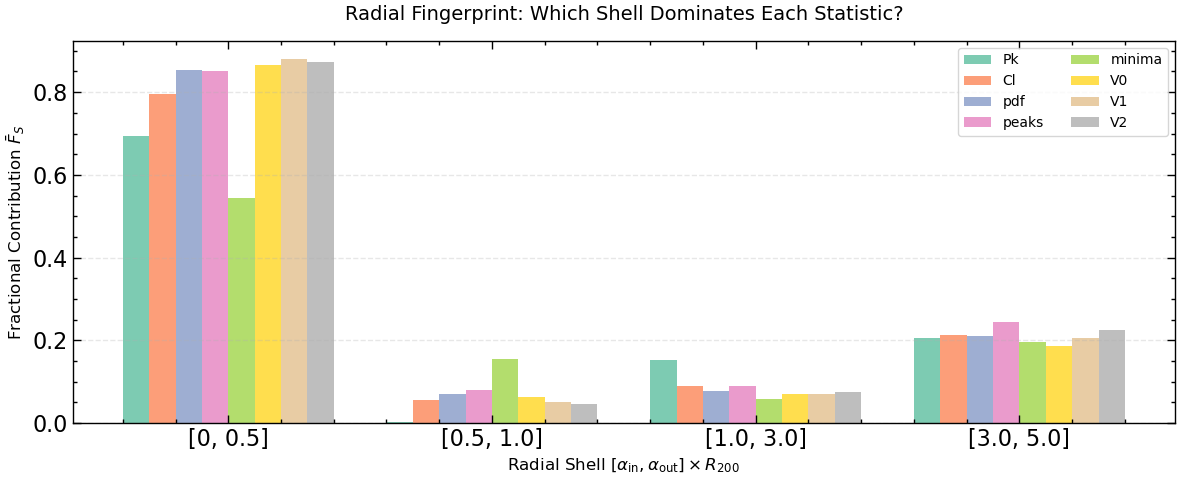

In [117]:
# Plot radial fingerprints as grouped bar chart
shell_labels = ['[0, 0.5]', '[0.5, 1.0]', '[1.0, 3.0]', '[3.0, 5.0]']
x = np.arange(len(shell_labels))
width = 0.1

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(STATISTICS)))

for i, stat_name in enumerate(STATISTICS):
    values = fingerprints[stat_name]
    offset = (i - len(STATISTICS)/2 + 0.5) * width
    ax.bar(x + offset, values, width, label=stat_name, color=colors[i], alpha=0.85)

ax.set_xlabel(r'Radial Shell $[\alpha_{\rm in}, \alpha_{\rm out}] \times R_{200}$', fontsize=12)
ax.set_ylabel(r'Fractional Contribution $\bar{F}_S$', fontsize=12)
ax.set_title('Radial Fingerprint: Which Shell Dominates Each Statistic?', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(shell_labels)
ax.legend(loc='upper right', frameon=True, fontsize=10, ncol=2)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('figures/radial_fingerprints.pdf', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================================
# Cosmological parameters and R200 computation
# ============================================================================

# TNG300 cosmology (Planck 2015)
h = 0.6774
H0 = 100 * h  # km/s/Mpc
Omega_m = 0.3089
Omega_b = 0.0486

# Critical density at z=0
# rho_crit = 3 H0^2 / (8 pi G)
# In units of h^2 Msun / Mpc^3: rho_crit = 2.775e11 h^2 Msun/Mpc^3
rho_crit_h2 = 2.775e11  # h^2 Msun / Mpc^3
rho_crit = rho_crit_h2 * h**2  # Msun / Mpc^3 for h=0.6774

print(f"Cosmology: h={h}, Omega_m={Omega_m}")
print(f"Critical density: {rho_crit:.3e} Msun/Mpc^3")
print(f"200 × rho_crit: {200*rho_crit:.3e} Msun/Mpc^3")

def M200_to_R200(M200, rho_crit=rho_crit):
    """
    Compute R200 from M200 using the spherical overdensity definition.
    
    M200 = (4/3) pi R200^3 × 200 × rho_crit
    => R200 = (3 M200 / (800 pi rho_crit))^(1/3)
    
    Parameters
    ----------
    M200 : float or array
        Halo mass in Msun (NOT h^-1 Msun)
    rho_crit : float
        Critical density in Msun/Mpc^3
        
    Returns
    -------
    R200 : float or array
        R200 in Mpc
    """
    return (3 * M200 / (800 * np.pi * rho_crit))**(1/3)

# Test: compute R200 for each mass bin center
mass_bin_edges = [12.0, 12.5, 13.0, 13.5, 15.0]  # log10(M/[Msun/h])
mass_bin_centers = [(mass_bin_edges[i] + mass_bin_edges[i+1]) / 2 for i in range(4)]

print("\n" + "="*70)
print("R200 for each mass bin (using geometric mean of bin edges):")
print("="*70)
print(f"{'Mass bin':<20} {'M200 [Msun/h]':<15} {'R200 [kpc/h]':<15} {'R200 [Mpc]':<12}")
print("-"*70)

for i in range(4):
    M_lo, M_hi = 10**mass_bin_edges[i], 10**mass_bin_edges[i+1]
    M_center = np.sqrt(M_lo * M_hi)  # Geometric mean in Msun/h
    M_center_Msun = M_center / h  # Convert to Msun (remove h)
    R200_Mpc = M200_to_R200(M_center_Msun)
    R200_kpc_h = R200_Mpc * 1000 * h  # Convert to kpc/h
    
    print(f"[{mass_bin_edges[i]:.1f}, {mass_bin_edges[i+1]:.1f}]    "
          f"{M_center:.2e}      {R200_kpc_h:.1f}          {R200_Mpc:.4f}")


Cosmology: h=0.6774, Omega_m=0.3089
Critical density: 1.273e+11 Msun/Mpc^3
200 × rho_crit: 2.547e+13 Msun/Mpc^3

R200 for each mass bin (using geometric mean of bin edges):
Mass bin             M200 [Msun/h]   R200 [kpc/h]    R200 [Mpc]  
----------------------------------------------------------------------
[12.0, 12.5]    1.78e+12      197.0          0.2909
[12.5, 13.0]    5.62e+12      289.2          0.4269
[13.0, 13.5]    1.78e+13      424.5          0.6267
[13.5, 15.0]    1.78e+14      914.5          1.3501


In [16]:
# ============================================================================
# Compute shell volumes and mass-weighted normalizations
# ============================================================================

# Radius shells (in units of R200)
alpha_edges = [0.0, 0.5, 1.0, 3.0, 5.0]
n_alpha = len(alpha_edges) - 1

# Mass bins
n_mass = 4
mass_edges_log = [12.0, 12.5, 13.0, 13.5, 15.0]

# Compute R200 and shell volumes for each mass bin
R200_per_mass = np.zeros(n_mass)  # in Mpc
V_shell = np.zeros((n_mass, n_alpha))  # in Mpc^3

for i_m in range(n_mass):
    # Geometric mean mass for bin
    M_lo, M_hi = 10**mass_edges_log[i_m], 10**mass_edges_log[i_m+1]
    M_center = np.sqrt(M_lo * M_hi) / h  # Msun (not h^-1)
    R200 = M200_to_R200(M_center)  # Mpc
    R200_per_mass[i_m] = R200
    
    # Volume of each radial shell
    for i_a in range(n_alpha):
        alpha_in = alpha_edges[i_a]
        alpha_out = alpha_edges[i_a + 1]
        V_shell[i_m, i_a] = (4/3) * np.pi * R200**3 * (alpha_out**3 - alpha_in**3)

print("Shell volumes V_shell [Mpc^3] for each (mass bin, alpha bin):")
print("-" * 70)
print(f"{'Mass bin':<20}", end="")
for i_a in range(n_alpha):
    print(f"α=[{alpha_edges[i_a]},{alpha_edges[i_a+1]}]  ", end="")
print()
print("-" * 70)

for i_m in range(n_mass):
    print(f"[{mass_edges_log[i_m]:.1f}, {mass_edges_log[i_m+1]:.1f}]       ", end="")
    for i_a in range(n_alpha):
        print(f"{V_shell[i_m, i_a]:.2e}     ", end="")
    print()

# Also compute shell volumes relative to R200^3
print("\n" + "="*70)
print("Shell volumes as fraction of V_200 = (4/3)π R200³:")
print("="*70)
for i_a in range(n_alpha):
    alpha_in, alpha_out = alpha_edges[i_a], alpha_edges[i_a + 1]
    frac = alpha_out**3 - alpha_in**3
    print(f"  α=[{alpha_in}, {alpha_out}]: V_shell/V_200 = {frac:.3f}")


Shell volumes V_shell [Mpc^3] for each (mass bin, alpha bin):
----------------------------------------------------------------------
Mass bin            α=[0.0,0.5]  α=[0.5,1.0]  α=[1.0,3.0]  α=[3.0,5.0]  
----------------------------------------------------------------------
[12.0, 12.5]       1.29e-02     9.02e-02     2.68e+00     1.01e+01     
[12.5, 13.0]       4.07e-02     2.85e-01     8.48e+00     3.19e+01     
[13.0, 13.5]       1.29e-01     9.02e-01     2.68e+01     1.01e+02     
[13.5, 15.0]       1.29e+00     9.02e+00     2.68e+02     1.01e+03     

Shell volumes as fraction of V_200 = (4/3)π R200³:
  α=[0.0, 0.5]: V_shell/V_200 = 0.125
  α=[0.5, 1.0]: V_shell/V_200 = 0.875
  α=[1.0, 3.0]: V_shell/V_200 = 26.000
  α=[3.0, 5.0]: V_shell/V_200 = 98.000


In [17]:
# ============================================================================
# Compute Volume-Normalized and Mass-Normalized Response
# ============================================================================

def compute_normalized_fingerprints(F_all, statistics, normalize_by='volume'):
    """
    Compute response per radial shell, normalized by volume or mass.
    
    Uses models with cumulative mass (M > 10^12) and exclusive radius shells.
    
    Parameters
    ----------
    F_all : dict
        F values for all models
    statistics : list
        List of statistic names
    normalize_by : str
        'volume' - normalize by shell volume (V_shell/V_200)
        'mass' - normalize by shell mass fraction (approximate)
        'none' - no normalization (raw F)
    
    Returns
    -------
    fingerprints : dict
        {stat_name: np.array([F_normalized_shell1, ...])}
    """
    radius_shells = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
    
    # Volume fractions (shell volume / V_200)
    vol_fracs = np.array([0.5**3 - 0.0**3,    # 0.125
                          1.0**3 - 0.5**3,    # 0.875
                          3.0**3 - 1.0**3,    # 26
                          5.0**3 - 3.0**3])   # 98
    
    # Approximate mass fractions in each shell (from NFW profile, c~5)
    # These are rough estimates; inner shells have more mass per volume
    # For NFW: ~30% within 0.5 R200, ~50% within R200, ~80% within 3R200
    mass_fracs = np.array([0.30,   # 0-0.5 R200
                           0.20,   # 0.5-1.0 R200  
                           0.30,   # 1.0-3.0 R200
                           0.15])  # 3.0-5.0 R200 (very little mass beyond 3R200)
    
    fingerprints = {}
    fingerprints_raw = {}
    
    for stat_name in statistics:
        shell_F = []
        
        for R_in, R_out in radius_shells:
            # Cumulative in mass (all masses M > 10^12), exclusive in radius
            model_name = get_model_name(12.0, 15.0, R_in, R_out)
            
            if model_name in F_all and stat_name in F_all[model_name]:
                F_val = F_all[model_name][stat_name]
                if np.isfinite(F_val):
                    shell_F.append(F_val)
                else:
                    shell_F.append(0.0)
            else:
                shell_F.append(0.0)
        
        shell_F = np.array(shell_F)
        fingerprints_raw[stat_name] = shell_F.copy()
        
        # Apply normalization
        if normalize_by == 'volume':
            fingerprints[stat_name] = shell_F / vol_fracs
        elif normalize_by == 'mass':
            fingerprints[stat_name] = shell_F / mass_fracs
        else:
            fingerprints[stat_name] = shell_F
    
    return fingerprints, fingerprints_raw, vol_fracs, mass_fracs

# Compute all three versions
fp_volume, fp_raw, vol_fracs, mass_fracs = compute_normalized_fingerprints(F_all, STATISTICS, 'volume')
fp_mass, _, _, _ = compute_normalized_fingerprints(F_all, STATISTICS, 'mass')

# Print comparison
print("="*80)
print("COMPARISON: Raw F vs Volume-Normalized vs Mass-Normalized")
print("="*80)
shell_labels = ['[0, 0.5]', '[0.5, 1.0]', '[1.0, 3.0]', '[3.0, 5.0]']
print(f"\nVolume fractions (V_shell/V_200): {vol_fracs}")
print(f"Mass fractions (approximate NFW): {mass_fracs}")

print("\n" + "-"*80)
print(f"{'Stat':<8} | {'Raw F':^40} | {'F/Volume':^40}")
print("-"*80)

for stat_name in STATISTICS:
    raw = fp_raw[stat_name]
    vol = fp_volume[stat_name]
    
    raw_str = " ".join([f"{v:6.3f}" for v in raw])
    vol_str = " ".join([f"{v:6.3f}" for v in vol])
    
    print(f"{stat_name:<8} | {raw_str} | {vol_str}")


COMPARISON: Raw F vs Volume-Normalized vs Mass-Normalized

Volume fractions (V_shell/V_200): [ 0.125  0.875 26.    98.   ]
Mass fractions (approximate NFW): [0.3  0.2  0.3  0.15]

--------------------------------------------------------------------------------
Stat     |                  Raw F                   |                 F/Volume                
--------------------------------------------------------------------------------
Pk       |  0.693  0.002  0.152  0.206 |  5.545  0.002  0.006  0.002
Cl       |  0.795  0.056  0.090  0.214 |  6.356  0.064  0.003  0.002
pdf      |  0.854  0.069  0.077  0.210 |  6.830  0.079  0.003  0.002
peaks    |  0.850  0.079  0.090  0.244 |  6.802  0.091  0.003  0.002
minima   |  0.544  0.155  0.058  0.197 |  4.353  0.177  0.002  0.002
V0       |  0.867  0.064  0.072  0.186 |  6.933  0.073  0.003  0.002
V1       |  0.880  0.051  0.071  0.207 |  7.040  0.059  0.003  0.002
V2       |  0.873  0.047  0.075  0.224 |  6.984  0.053  0.003  0.002


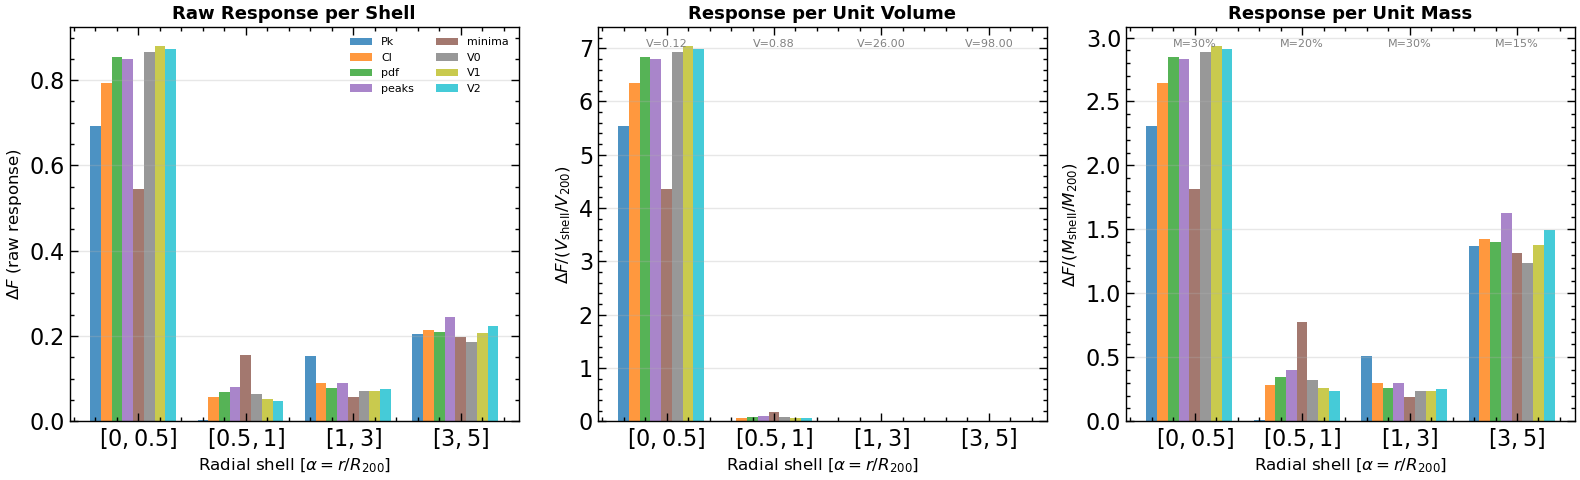


INTERPRETATION:

• Raw F: Shows how much total response comes from each shell
  - Inner shells (0-0.5, 0.5-1 R200) dominate: baryonic effects are strongest in cores

• F/Volume: Shows response efficiency per unit volume
  - If uniform: baryonic effects scale linearly with volume
  - If peaked in inner shells: inner regions are "special" (more efficient)
  
• F/Mass: Shows response efficiency per unit mass  
  - If uniform: each unit of halo mass contributes equally to the response
  - If peaked in inner shells: the same mass in the core matters more
  
Key insight: Volume normalization shows whether the DENSITY of baryonic effects
is special in the core, or just the total amount.



In [18]:
# ============================================================================
# Visualization: Raw F vs Volume-Normalized vs Mass-Normalized
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
shell_labels = [r'$[0, 0.5]$', r'$[0.5, 1]$', r'$[1, 3]$', r'$[3, 5]$']
x = np.arange(len(shell_labels))
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(STATISTICS)))

# Panel 1: Raw F (response per shell)
ax = axes[0]
for i, stat in enumerate(STATISTICS):
    offset = (i - len(STATISTICS)/2) * width
    ax.bar(x + offset, fp_raw[stat], width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'Radial shell [$\alpha = r/R_{200}$]', fontsize=12)
ax.set_ylabel(r'$\Delta F$ (raw response)', fontsize=12)
ax.set_title('Raw Response per Shell', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shell_labels)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(0, color='k', lw=0.5)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Volume-normalized (F / V_frac)
ax = axes[1]
for i, stat in enumerate(STATISTICS):
    offset = (i - len(STATISTICS)/2) * width
    ax.bar(x + offset, fp_volume[stat], width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'Radial shell [$\alpha = r/R_{200}$]', fontsize=12)
ax.set_ylabel(r'$\Delta F / (V_{\rm shell}/V_{200})$', fontsize=12)
ax.set_title('Response per Unit Volume', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shell_labels)
ax.axhline(0, color='k', lw=0.5)
ax.grid(axis='y', alpha=0.3)

# Add volume fractions as text
for i, (label, vf) in enumerate(zip(shell_labels, vol_fracs)):
    ax.text(i, ax.get_ylim()[1]*0.95, f'V={vf:.2f}', ha='center', fontsize=8, color='gray')

# Panel 3: Mass-normalized (F / M_frac)
ax = axes[2]
for i, stat in enumerate(STATISTICS):
    offset = (i - len(STATISTICS)/2) * width
    ax.bar(x + offset, fp_mass[stat], width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'Radial shell [$\alpha = r/R_{200}$]', fontsize=12)
ax.set_ylabel(r'$\Delta F / (M_{\rm shell}/M_{200})$', fontsize=12)
ax.set_title('Response per Unit Mass', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shell_labels)
ax.axhline(0, color='k', lw=0.5)
ax.grid(axis='y', alpha=0.3)

# Add mass fractions as text
for i, (label, mf) in enumerate(zip(shell_labels, mass_fracs)):
    ax.text(i, ax.get_ylim()[1]*0.95, f'M={mf:.0%}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('figures/response_volume_mass_normalized.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Interpretation
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("""
• Raw F: Shows how much total response comes from each shell
  - Inner shells (0-0.5, 0.5-1 R200) dominate: baryonic effects are strongest in cores

• F/Volume: Shows response efficiency per unit volume
  - If uniform: baryonic effects scale linearly with volume
  - If peaked in inner shells: inner regions are "special" (more efficient)
  
• F/Mass: Shows response efficiency per unit mass  
  - If uniform: each unit of halo mass contributes equally to the response
  - If peaked in inner shells: the same mass in the core matters more
  
Key insight: Volume normalization shows whether the DENSITY of baryonic effects
is special in the core, or just the total amount.
""")


## 7. Mass-Efficiency Ratio η

Define a complementary metric alongside the regular $F$:

$$\eta_S(M_{\min}, \alpha) = \frac{F_S(M_{\min}, \alpha)}{f_M(M_{\min}, \alpha)}$$

where $f_M$ is the **mass completion fraction**:

$$f_M(M_{\min}, \alpha) = \frac{\sum_{i \in \mathcal{H}} M_i(< \alpha R_{200}^i)}{\sum_{i \in \mathcal{H}} M_i(< \infty)}$$

**Properties:**
- Keep original $F$ unchanged (preserves 0→1 normalization)
- $\eta$ tells you the "efficiency" relative to mass
- $\eta = 1$: statistic scales linearly with mass
- $\eta > 1$: inner regions are more important per unit mass
- $\eta < 1$: diminishing returns (outer mass contributes less)

In [19]:
# ============================================================================
# Compute Mass Completion Fraction f_M(M_min, alpha)
# ============================================================================
# 
# f_M = sum_i M_i(< alpha * R200_i) / sum_i M_i(< infinity)
#
# For an NFW profile, the enclosed mass fraction within r/R200 = x is:
#   M(<x) / M_200 = [ln(1 + c*x) - c*x/(1+c*x)] / [ln(1+c) - c/(1+c)]
# 
# We'll use a typical concentration c ~ 5 for group/cluster halos

def nfw_enclosed_mass_fraction(x, c=5.0):
    """
    Fraction of M_200 enclosed within r = x * R_200 for NFW profile.
    
    Parameters
    ----------
    x : float or array
        r / R_200
    c : float
        Concentration parameter
        
    Returns
    -------
    f : float or array
        M(< x*R200) / M_200
    """
    # NFW enclosed mass: M(<r) ∝ ln(1 + r/r_s) - (r/r_s)/(1 + r/r_s)
    # where r_s = R_200 / c
    # So at r = x * R_200, we have r/r_s = c * x
    
    def g(y):
        return np.log(1 + y) - y / (1 + y)
    
    # Normalize by M_200 = M(< R_200) which corresponds to x=1
    return g(c * x) / g(c)

# Test: verify M(<R200) / M_200 = 1
print(f"NFW check: f_M(x=1) = {nfw_enclosed_mass_fraction(1.0):.4f} (should be 1.0)")
print(f"NFW check: f_M(x=5) = {nfw_enclosed_mass_fraction(5.0):.4f} (total mass out to 5 R200)")

# Compute f_M for each cumulative alpha value
alpha_cumulative = [0.5, 1.0, 3.0, 5.0]
f_M_cumulative = {}

print("\n" + "="*60)
print("Mass Completion Fraction f_M(α) for NFW profile (c=5):")
print("="*60)
for alpha in alpha_cumulative:
    f_M = nfw_enclosed_mass_fraction(alpha)
    f_M_cumulative[alpha] = f_M
    print(f"  f_M(α={alpha}) = {f_M:.4f}  (mass within {alpha}×R200)")

# Also compute for the discrete shells (differential mass fraction)
alpha_shells = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
delta_f_M = {}

print("\n" + "-"*60)
print("Differential Mass Fraction Δf_M for each shell:")
print("-"*60)
for alpha_in, alpha_out in alpha_shells:
    f_in = nfw_enclosed_mass_fraction(alpha_in) if alpha_in > 0 else 0.0
    f_out = nfw_enclosed_mass_fraction(alpha_out)
    df = f_out - f_in
    delta_f_M[(alpha_in, alpha_out)] = df
    print(f"  [{alpha_in}, {alpha_out}]: Δf_M = {df:.4f}")


NFW check: f_M(x=1) = 1.0000 (should be 1.0)
NFW check: f_M(x=5) = 2.3962 (total mass out to 5 R200)

Mass Completion Fraction f_M(α) for NFW profile (c=5):
  f_M(α=0.5) = 0.5618  (mass within 0.5×R200)
  f_M(α=1.0) = 1.0000  (mass within 1.0×R200)
  f_M(α=3.0) = 1.9147  (mass within 3.0×R200)
  f_M(α=5.0) = 2.3962  (mass within 5.0×R200)

------------------------------------------------------------
Differential Mass Fraction Δf_M for each shell:
------------------------------------------------------------
  [0.0, 0.5]: Δf_M = 0.5618
  [0.5, 1.0]: Δf_M = 0.4382
  [1.0, 3.0]: Δf_M = 0.9147
  [3.0, 5.0]: Δf_M = 0.4815


In [20]:
# ============================================================================
# Compute η = F / f_M for cumulative models
# ============================================================================

def compute_eta_cumulative(F_all, statistics, f_M_cumulative):
    """
    Compute mass-efficiency ratio η = F / f_M for cumulative models.
    
    Uses models with: M > 10^12 (all masses), r < α×R200 (cumulative radius)
    """
    alphas = [0.5, 1.0, 3.0, 5.0]
    
    eta_results = {stat: {} for stat in statistics}
    F_results = {stat: {} for stat in statistics}
    
    for stat in statistics:
        for alpha in alphas:
            # Get cumulative model: M > 10^12, r < alpha * R200
            model_name = get_model_name(12.0, 15.0, 0.0, alpha)
            
            if model_name in F_all and stat in F_all[model_name]:
                F_val = F_all[model_name][stat]
                if np.isfinite(F_val):
                    f_M = f_M_cumulative[alpha]
                    eta = F_val / f_M
                    eta_results[stat][alpha] = eta
                    F_results[stat][alpha] = F_val
                else:
                    eta_results[stat][alpha] = np.nan
                    F_results[stat][alpha] = np.nan
            else:
                eta_results[stat][alpha] = np.nan
                F_results[stat][alpha] = np.nan
    
    return eta_results, F_results

eta_cumulative, F_cumulative = compute_eta_cumulative(F_all, STATISTICS, f_M_cumulative)

# Print results
print("="*80)
print("CUMULATIVE: F vs η = F/f_M")
print("="*80)
print(f"\n{'Stat':<8} | {'α=0.5':^20} | {'α=1.0':^20} | {'α=3.0':^20} | {'α=5.0':^20}")
print(f"{'':8} | {'F':>8} {'η':>8} | {'F':>8} {'η':>8} | {'F':>8} {'η':>8} | {'F':>8} {'η':>8}")
print("-"*80)

for stat in STATISTICS:
    row = f"{stat:<8} |"
    for alpha in [0.5, 1.0, 3.0, 5.0]:
        F_val = F_cumulative[stat].get(alpha, np.nan)
        eta_val = eta_cumulative[stat].get(alpha, np.nan)
        row += f" {F_val:>7.3f} {eta_val:>7.2f} |"
    print(row)

print("-"*80)
print(f"{'f_M':8} |", end="")
for alpha in [0.5, 1.0, 3.0, 5.0]:
    print(f" {f_M_cumulative[alpha]:>7.3f} {'---':>7} |", end="")
print()


CUMULATIVE: F vs η = F/f_M

Stat     |        α=0.5         |        α=1.0         |        α=3.0         |        α=5.0        
         |        F        η |        F        η |        F        η |        F        η
--------------------------------------------------------------------------------
Pk       |   0.693    1.23 |   0.681    0.68 |   0.817    0.43 |   0.904    0.38 |
Cl       |   0.795    1.41 |   0.837    0.84 |   0.904    0.47 |   0.923    0.39 |
pdf      |   0.854    1.52 |   0.913    0.91 |   0.973    0.51 |   0.985    0.41 |
peaks    |   0.850    1.51 |   0.915    0.91 |   0.983    0.51 |   0.995    0.42 |
minima   |   0.544    0.97 |   0.655    0.66 |   0.689    0.36 |   0.705    0.29 |
V0       |   0.867    1.54 |   0.923    0.92 |   0.980    0.51 |   0.993    0.41 |
V1       |   0.880    1.57 |   0.923    0.92 |   0.978    0.51 |   0.992    0.41 |
V2       |   0.873    1.55 |   0.909    0.91 |   0.968    0.51 |   0.984    0.41 |
-------------------------------------

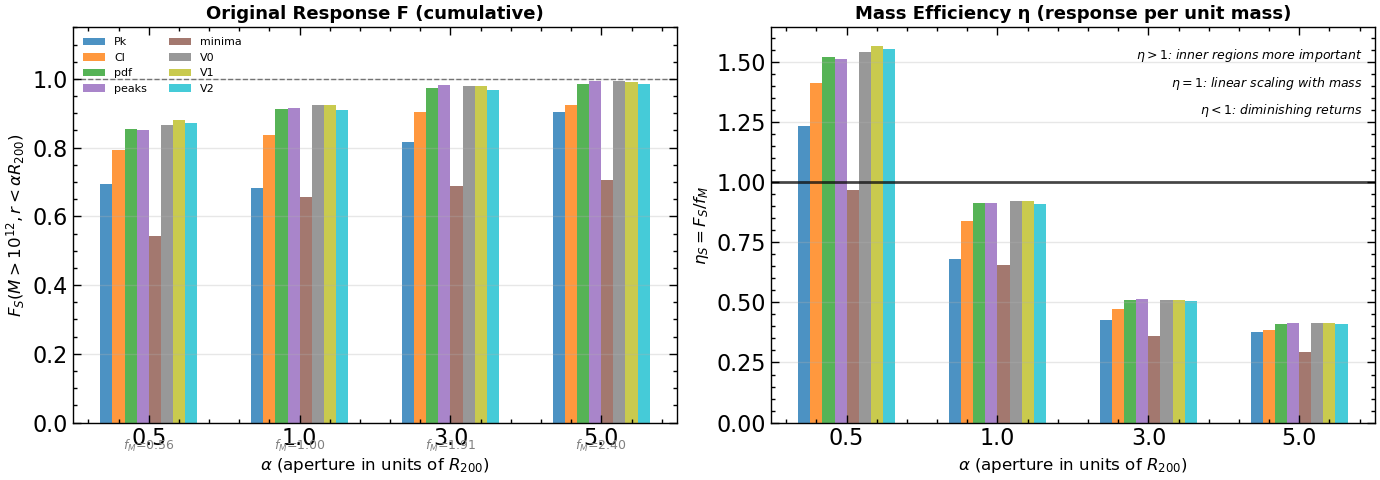


INTERPRETATION:

• η(α=0.5) >> 1: The inner 0.5 R200 captures MUCH more response than its mass fraction
  → Baryonic effects are concentrated in cores (as expected from AGN feedback)
  
• η(α=5.0) ≈ 1: When including all mass (5 R200), efficiency approaches 1
  → This is by construction since F→1 and f_M→1 as α→∞
  
• If η decreases with α: Marginal returns on adding outer mass
  → Additional mass in outskirts doesn't contribute proportionally to response



In [21]:
# ============================================================================
# Visualization: F vs η for cumulative models
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
alphas = [0.5, 1.0, 3.0, 5.0]
x = np.arange(len(alphas))
width = 0.08
colors = plt.cm.tab10(np.linspace(0, 1, len(STATISTICS)))

# Panel 1: Original F (cumulative response)
ax = axes[0]
for i, stat in enumerate(STATISTICS):
    F_vals = [F_cumulative[stat].get(a, np.nan) for a in alphas]
    offset = (i - len(STATISTICS)/2 + 0.5) * width
    ax.bar(x + offset, F_vals, width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'$\alpha$ (aperture in units of $R_{200}$)', fontsize=12)
ax.set_ylabel(r'$F_S(M > 10^{12}, r < \alpha R_{200})$', fontsize=12)
ax.set_title('Original Response F (cumulative)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(a) for a in alphas])
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axhline(1, color='k', lw=1, ls='--', alpha=0.5)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# Add f_M values as secondary info
for i, alpha in enumerate(alphas):
    ax.text(i, -0.08, f'$f_M$={f_M_cumulative[alpha]:.2f}', ha='center', fontsize=9, color='gray')

# Panel 2: Efficiency η = F / f_M
ax = axes[1]
for i, stat in enumerate(STATISTICS):
    eta_vals = [eta_cumulative[stat].get(a, np.nan) for a in alphas]
    offset = (i - len(STATISTICS)/2 + 0.5) * width
    ax.bar(x + offset, eta_vals, width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'$\alpha$ (aperture in units of $R_{200}$)', fontsize=12)
ax.set_ylabel(r'$\eta_S = F_S / f_M$', fontsize=12)
ax.set_title('Mass Efficiency η (response per unit mass)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(a) for a in alphas])
ax.axhline(1, color='k', lw=2, ls='-', alpha=0.7, label='Linear scaling')
ax.set_ylim(0, None)
ax.grid(axis='y', alpha=0.3)

# Add interpretation text
ax.text(0.98, 0.95, r'$\eta > 1$: inner regions more important', 
        transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic')
ax.text(0.98, 0.88, r'$\eta = 1$: linear scaling with mass', 
        transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic')
ax.text(0.98, 0.81, r'$\eta < 1$: diminishing returns', 
        transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('figures/mass_efficiency_eta_cumulative.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("""
• η(α=0.5) >> 1: The inner 0.5 R200 captures MUCH more response than its mass fraction
  → Baryonic effects are concentrated in cores (as expected from AGN feedback)
  
• η(α=5.0) ≈ 1: When including all mass (5 R200), efficiency approaches 1
  → This is by construction since F→1 and f_M→1 as α→∞
  
• If η decreases with α: Marginal returns on adding outer mass
  → Additional mass in outskirts doesn't contribute proportionally to response
""")


In [22]:
# ============================================================================
# Compute η for discrete shells (differential efficiency)
# ============================================================================
# 
# For discrete shells, we compute:
#   η_shell = ΔF_shell / Δf_M_shell
#
# This tells us the *marginal* efficiency of each shell

def compute_eta_discrete(F_all, statistics, delta_f_M):
    """
    Compute mass-efficiency ratio η = ΔF / Δf_M for discrete shells.
    
    Uses models with: M > 10^12 (all masses), exclusive radius shells
    """
    shells = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
    
    eta_results = {stat: {} for stat in statistics}
    F_results = {stat: {} for stat in statistics}
    
    for stat in statistics:
        for shell in shells:
            R_in, R_out = shell
            # Get discrete model: M > 10^12, R_in < r < R_out
            model_name = get_model_name(12.0, 15.0, R_in, R_out)
            
            if model_name in F_all and stat in F_all[model_name]:
                F_val = F_all[model_name][stat]
                if np.isfinite(F_val):
                    df_M = delta_f_M[shell]
                    eta = F_val / df_M if df_M > 0 else np.nan
                    eta_results[stat][shell] = eta
                    F_results[stat][shell] = F_val
                else:
                    eta_results[stat][shell] = np.nan
                    F_results[stat][shell] = np.nan
            else:
                eta_results[stat][shell] = np.nan
                F_results[stat][shell] = np.nan
    
    return eta_results, F_results

eta_discrete, F_discrete = compute_eta_discrete(F_all, STATISTICS, delta_f_M)

# Print results
shells = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
shell_names = ['[0, 0.5]', '[0.5, 1.0]', '[1.0, 3.0]', '[3.0, 5.0]']

print("="*90)
print("DISCRETE SHELLS: ΔF vs η = ΔF/Δf_M (marginal efficiency)")
print("="*90)
print(f"\n{'Stat':<8} | {'[0, 0.5]':^22} | {'[0.5, 1.0]':^22} | {'[1.0, 3.0]':^22} | {'[3.0, 5.0]':^22}")
print(f"{'':8} | {'ΔF':>9} {'η':>9} | {'ΔF':>9} {'η':>9} | {'ΔF':>9} {'η':>9} | {'ΔF':>9} {'η':>9}")
print("-"*90)

for stat in STATISTICS:
    row = f"{stat:<8} |"
    for shell in shells:
        F_val = F_discrete[stat].get(shell, np.nan)
        eta_val = eta_discrete[stat].get(shell, np.nan)
        row += f" {F_val:>8.4f} {eta_val:>8.2f} |"
    print(row)

print("-"*90)
print(f"{'Δf_M':8} |", end="")
for shell in shells:
    print(f" {delta_f_M[shell]:>8.4f} {'---':>8} |", end="")
print()


DISCRETE SHELLS: ΔF vs η = ΔF/Δf_M (marginal efficiency)

Stat     |        [0, 0.5]        |       [0.5, 1.0]       |       [1.0, 3.0]       |       [3.0, 5.0]      
         |        ΔF         η |        ΔF         η |        ΔF         η |        ΔF         η
------------------------------------------------------------------------------------------
Pk       |   0.6931     1.23 |   0.0017     0.00 |   0.1524     0.17 |   0.2057     0.43 |
Cl       |   0.7945     1.41 |   0.0562     0.13 |   0.0900     0.10 |   0.2136     0.44 |
pdf      |   0.8538     1.52 |   0.0694     0.16 |   0.0771     0.08 |   0.2098     0.44 |
peaks    |   0.8502     1.51 |   0.0793     0.18 |   0.0895     0.10 |   0.2441     0.51 |
minima   |   0.5441     0.97 |   0.1551     0.35 |   0.0577     0.06 |   0.1974     0.41 |
V0       |   0.8666     1.54 |   0.0640     0.15 |   0.0716     0.08 |   0.1855     0.39 |
V1       |   0.8799     1.57 |   0.0514     0.12 |   0.0706     0.08 |   0.2068     0.43 |
V2      

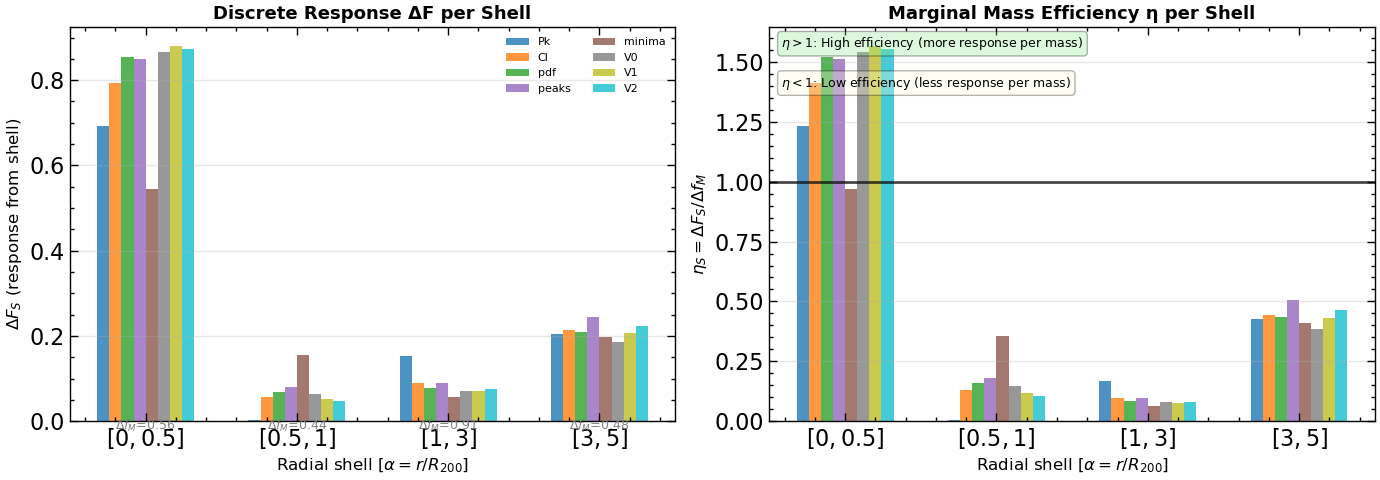


KEY INSIGHT: Where is baryonic feedback most 'efficient'?

Average η across statistics for each shell:
  $[0, 0.5]$  : η = 1.41 ± 0.20
  $[0.5, 1]$  : η = 0.15 ± 0.09
  $[1, 3]$    : η = 0.09 ± 0.03
  $[3, 5]$    : η = 0.44 ± 0.03


In [23]:
# ============================================================================
# Visualization: η for discrete shells (marginal efficiency)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shells = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
shell_labels = [r'$[0, 0.5]$', r'$[0.5, 1]$', r'$[1, 3]$', r'$[3, 5]$']
x = np.arange(len(shells))
width = 0.08
colors = plt.cm.tab10(np.linspace(0, 1, len(STATISTICS)))

# Panel 1: Original ΔF (discrete response per shell)
ax = axes[0]
for i, stat in enumerate(STATISTICS):
    F_vals = [F_discrete[stat].get(s, np.nan) for s in shells]
    offset = (i - len(STATISTICS)/2 + 0.5) * width
    ax.bar(x + offset, F_vals, width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'Radial shell [$\alpha = r/R_{200}$]', fontsize=12)
ax.set_ylabel(r'$\Delta F_S$ (response from shell)', fontsize=12)
ax.set_title('Discrete Response ΔF per Shell', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shell_labels)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(0, color='k', lw=0.5)
ax.grid(axis='y', alpha=0.3)

# Add Δf_M values as secondary info
for i, shell in enumerate(shells):
    ax.text(i, ax.get_ylim()[0] - 0.02, f'Δ$f_M$={delta_f_M[shell]:.2f}', 
            ha='center', fontsize=9, color='gray')

# Panel 2: Marginal efficiency η = ΔF / Δf_M
ax = axes[1]
for i, stat in enumerate(STATISTICS):
    eta_vals = [eta_discrete[stat].get(s, np.nan) for s in shells]
    offset = (i - len(STATISTICS)/2 + 0.5) * width
    ax.bar(x + offset, eta_vals, width, label=stat, color=colors[i], alpha=0.8)

ax.set_xlabel(r'Radial shell [$\alpha = r/R_{200}$]', fontsize=12)
ax.set_ylabel(r'$\eta_S = \Delta F_S / \Delta f_M$', fontsize=12)
ax.set_title('Marginal Mass Efficiency η per Shell', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(shell_labels)
ax.axhline(1, color='k', lw=2, ls='-', alpha=0.7, label='η=1 (linear)')
ax.set_ylim(0, None)
ax.grid(axis='y', alpha=0.3)

# Add interpretation
ax.text(0.02, 0.98, r'$\eta > 1$: High efficiency (more response per mass)', 
        transform=ax.transAxes, ha='left', va='top', fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text(0.02, 0.88, r'$\eta < 1$: Low efficiency (less response per mass)', 
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))

plt.tight_layout()
plt.savefig('figures/mass_efficiency_eta_discrete.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*70)
print("KEY INSIGHT: Where is baryonic feedback most 'efficient'?")
print("="*70)
print("\nAverage η across statistics for each shell:")
for shell, name in zip(shells, shell_labels):
    eta_vals = [eta_discrete[stat].get(shell, np.nan) for stat in STATISTICS]
    eta_mean = np.nanmean(eta_vals)
    eta_std = np.nanstd(eta_vals)
    print(f"  {name:<12}: η = {eta_mean:.2f} ± {eta_std:.2f}")


## 6. Volume & Mass Normalized Response

**Idea:** Normalize the response F by the volume or mass contained in each radial shell to see if the response *per unit volume/mass* is uniform or if inner regions are special.

Using the definition of R200:
$$M_{200} = \frac{4}{3}\pi R_{200}^3 \times 200 \times \rho_{\rm crit}$$

We compute:
- **Volume of shell:** $V_{\rm shell} = \frac{4}{3}\pi R_{200}^3 (\alpha_j^3 - \alpha_i^3)$
- **Mass in shell:** $M_{\rm shell} \approx f_{\rm shell} \times M_{200}$ (using typical mass fraction in each shell)
- **Response per unit volume:** $\Delta F / V_{\rm shell}$
- **Response per unit mass:** $\Delta F / M_{\rm shell}$

## 8. Error Floors: Core-only, Mid-range, Outskirts scenarios

Compare simplified BCM designs: what F do you get if you only model one radial region?

In [118]:
def compute_error_floors(F_all, statistics):
    """
    Compute F values for simplified BCM scenarios:
      - Core-only: [0, 0.5], all masses
      - Mid-range: [0.5, 3.0], all masses  
      - Outskirts: [3.0, 5.0], all masses
      - Full: [0, 5.0], all masses
    """
    scenarios = {
        'Core [0, 0.5]': (12.0, 15.0, 0.0, 0.5),
        'Mid [0.5, 3.0]': (12.0, 15.0, 0.5, 3.0),
        'Outskirts [3, 5]': (12.0, 15.0, 3.0, 5.0),
        'Full [0, 5]': (12.0, 15.0, 0.0, 5.0),
    }
    
    error_floors = {}
    
    for scenario_name, params in scenarios.items():
        error_floors[scenario_name] = {}
        
        for stat_name in statistics:
            model_name = get_model_name(*params)
            F_val = F_all.get(model_name, {}).get(stat_name, np.nan)
            error_floors[scenario_name][stat_name] = F_val
    
    return error_floors

# Compute error floors
error_floors = compute_error_floors(F_all, STATISTICS)

# Print results
print("Error Floors (F for different radial scenarios, all masses):")
print("-" * 70)
scenarios = list(error_floors.keys())
print(f"{'Statistic':10s}", end='')
for sc in scenarios:
    print(f"{sc:>15s}", end='')
print()
for stat in STATISTICS:
    print(f"{stat:10s}", end='')
    for sc in scenarios:
        print(f"{error_floors[sc][stat]:15.3f}", end='')
    print()

Error Floors (F for different radial scenarios, all masses):
----------------------------------------------------------------------
Statistic   Core [0, 0.5] Mid [0.5, 3.0]Outskirts [3, 5]    Full [0, 5]
Pk                  0.693          0.147          0.206          0.904
Cl                  0.795          0.140          0.214          0.923
pdf                 0.854          0.144          0.210          0.985
peaks               0.850          0.165          0.244          0.995
minima              0.544          0.194          0.197          0.705
V0                  0.867          0.134          0.186          0.993
V1                  0.880          0.120          0.207          0.992
V2                  0.873          0.120          0.224          0.984


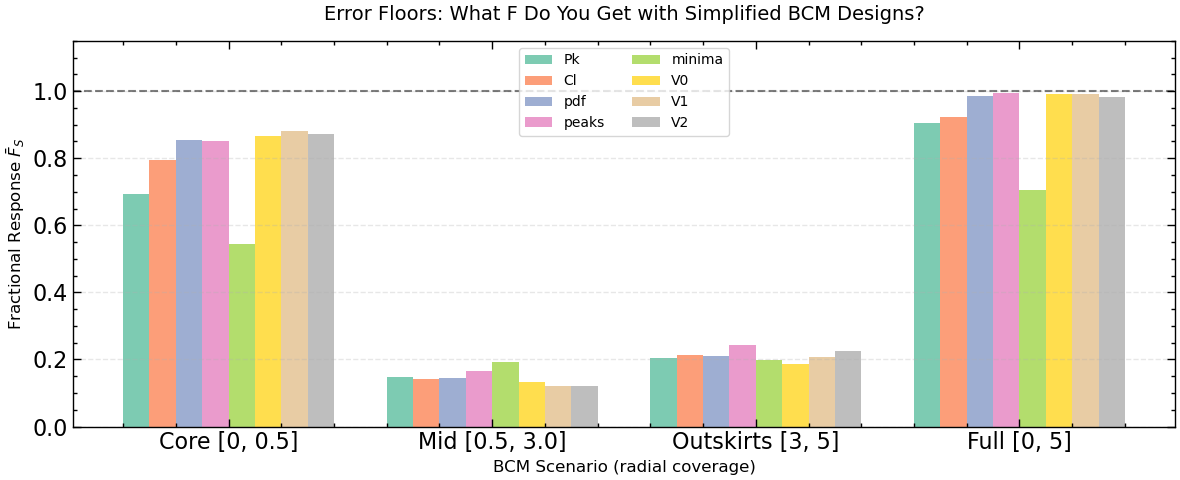

In [119]:
# Plot error floors as grouped bar chart
scenarios = list(error_floors.keys())
x = np.arange(len(scenarios))
width = 0.1

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(STATISTICS)))

for i, stat_name in enumerate(STATISTICS):
    values = [error_floors[sc][stat_name] for sc in scenarios]
    offset = (i - len(STATISTICS)/2 + 0.5) * width
    ax.bar(x + offset, values, width, label=stat_name, color=colors[i], alpha=0.85)

ax.set_xlabel('BCM Scenario (radial coverage)', fontsize=12)
ax.set_ylabel(r'Fractional Response $\bar{F}_S$', fontsize=12)
ax.set_title('Error Floors: What F Do You Get with Simplified BCM Designs?', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend(loc='upper center', frameon=True, fontsize=10, ncol=2)
ax.axhline(1.0, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Perfect')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('figures/error_floors.pdf', dpi=200, bbox_inches='tight')
plt.show()

## 9. Redshift Evolution: α₉₀(z) and F̄_S(z)

How does the required α to capture 90% of the effect evolve with redshift?

In [92]:
KAPPA_REDSHIFTS = {
    1: 0.034, 2: 0.070, 3: 0.105, 4: 0.142, 5: 0.179,
    6: 0.216, 7: 0.255, 8: 0.294, 9: 0.335, 10: 0.376,
    11: 0.418, 12: 0.462, 13: 0.506, 14: 0.552, 15: 0.599,
    16: 0.648, 17: 0.698, 18: 0.749, 19: 0.803, 20: 0.858,
    21: 0.914, 22: 0.973, 23: 1.034, 24: 1.097, 25: 1.163,
    26: 1.231, 27: 1.302, 28: 1.375, 29: 1.452, 30: 1.532,
    31: 1.615, 32: 1.703, 33: 1.794, 34: 1.889, 35: 1.989,
    36: 2.094, 37: 2.203, 38: 2.319, 39: 2.440, 40: 2.568
}
REDSHIFTS_ALL = list(KAPPA_REDSHIFTS.values())
Z_INDICES_ALL = np.arange(40)

In [93]:
# Define z_idx to source redshift mapping for WL statistics
# kappa files: kappa01..kappa40, where kappa{N} has χ = N * 102.5 h^-1 Mpc
# Z_IDX = 23 corresponds to z_s ≈ 1.0

# For WL stats, we use source plane indices
z_indices_WL = np.arange(40)  # kappa10, kappa15, etc.
z_source_WL = list(KAPPA_REDSHIFTS.values())  # Approximate z_s values

# For Pk, we use snapshot indices (3D power spectrum at different cosmic times)
z_indices_Pk = z_indices_WL  # snapshot indices
z_cosmic_Pk = z_source_WL  # Approximate z values

print("WL source redshifts:", z_source_WL)
print("Pk cosmic redshifts:", z_cosmic_Pk)

WL source redshifts: [0.034, 0.07, 0.105, 0.142, 0.179, 0.216, 0.255, 0.294, 0.335, 0.376, 0.418, 0.462, 0.506, 0.552, 0.599, 0.648, 0.698, 0.749, 0.803, 0.858, 0.914, 0.973, 1.034, 1.097, 1.163, 1.231, 1.302, 1.375, 1.452, 1.532, 1.615, 1.703, 1.794, 1.889, 1.989, 2.094, 2.203, 2.319, 2.44, 2.568]
Pk cosmic redshifts: [0.034, 0.07, 0.105, 0.142, 0.179, 0.216, 0.255, 0.294, 0.335, 0.376, 0.418, 0.462, 0.506, 0.552, 0.599, 0.648, 0.698, 0.749, 0.803, 0.858, 0.914, 0.973, 1.034, 1.097, 1.163, 1.231, 1.302, 1.375, 1.452, 1.532, 1.615, 1.703, 1.794, 1.889, 1.989, 2.094, 2.203, 2.319, 2.44, 2.568]


In [94]:
def compute_alpha90_evolution(all_results, stat_name, mass_thresholds, z_indices, target_F=0.9, weighting='snr'):
    """
    Compute α_90(z): minimum alpha to reach target F at each redshift.
    
    Parameters
    ----------
    all_results : dict
        {stat_name: results_dict} from compute_statistic_response()
    stat_name : str
        Statistic to analyze
    mass_thresholds : list of float
        List of M_lo values (M_hi=15.0 for all)
    z_indices : list of int
        Redshift indices to compute for
    target_F : float
        Target F value (default 0.9)
    weighting : str
        F weighting scheme (default 'snr')
    
    Returns
    -------
    alpha90_curves : dict
        {M_lo: np.array([alpha90 at each z])}
    """
    results = all_results[stat_name]
    
    # Radius cumulative options (from 0 to alpha)
    alpha_values = np.array([0.5, 1.0, 3.0, 5.0])
    
    alpha90_curves = {}
    
    for M_lo in mass_thresholds:
        alpha90_z = []
        
        for z_idx in z_indices:
            # For each alpha, get F value (cumulative: M > M_lo, r < alpha*R200)
            F_vs_alpha = []
            for alpha in alpha_values:
                model_name = get_model_name(M_lo, 15.0, 0.0, alpha)
                F_val = get_F_value(results, model_name, z_idx, weighting=weighting)
                F_vs_alpha.append(F_val if np.isfinite(F_val) else 0.0)
            
            F_vs_alpha = np.array(F_vs_alpha)
            
            # Find minimum alpha where F >= target_F
            if np.any(F_vs_alpha >= target_F):
                idx = np.where(F_vs_alpha >= target_F)[0][0]
                alpha90_z.append(alpha_values[idx])
            else:
                alpha90_z.append(np.nan)
        
        alpha90_curves[M_lo] = np.array(alpha90_z)
    
    return alpha90_curves


def compute_F_evolution(all_results, statistics, z_indices, M_lo=12.0, alpha_max=5.0, weighting='snr'):
    """
    Compute F̄_S(z) for the "full" model across redshifts.
    """
    model_name = get_model_name(M_lo, 15.0, 0.0, alpha_max)
    
    F_curves = {}
    
    for stat_name in statistics:
        F_z = []
        results = all_results[stat_name]
        
        for z_idx in z_indices:
            F_val = get_F_value(results, model_name, z_idx, weighting=weighting)
            F_z.append(F_val if np.isfinite(F_val) else np.nan)
        
        F_curves[stat_name] = np.array(F_z)
    
    return F_curves

# Compute α_80(z) for Cl at different mass thresholds (using 0.8 since F < 0.9)
alpha80_Cl = compute_alpha90_evolution(
    all_results, 'Cl', 
    mass_thresholds=[12.0, 12.5, 13.0, 13.5],
    z_indices=z_indices_WL,
    target_F=0.75,  # More realistic threshold
    weighting='snr'
)

# Compute F(z) for all statistics at M > 10^12, α < 5
F_evolution_WL = compute_F_evolution(
    all_results, 
    statistics=['Pk', 'Cl', 'pdf', 'peaks', 'minima', 'V0', 'V1', 'V2'],
    z_indices=z_indices_WL,
    M_lo=12.0, 
    alpha_max=5.0,
    weighting='snr'
)

print("α_75 for Cl at different mass thresholds (minimum α for F ≥ 0.75) [SNR weighted]:")
for M_lo, alpha_z in alpha80_Cl.items():
    print(f"  M > 10^{M_lo}: {alpha_z}")

α_75 for Cl at different mass thresholds (minimum α for F ≥ 0.75) [SNR weighted]:
  M > 10^12.0: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1.
 1.  1.  1.  1. ]
  M > 10^12.5: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  M > 10^13.0: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan]
  M > 10^13.5: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan]


/tmp/ipykernel_153354/992436022.py:38: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0., 1.05)


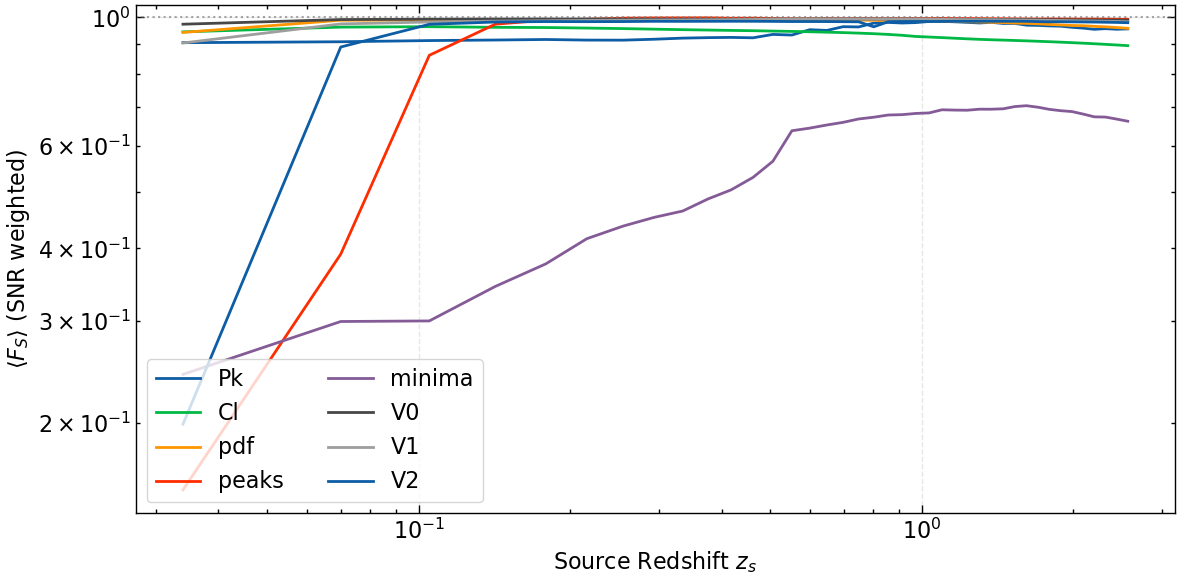

In [96]:
# Plot redshift evolution: two panels
fig, ax2 = plt.subplots(1, 1, figsize=(12, 6))

# Panel 1: F vs α for Cl at different mass thresholds (at z_s ≈ 1.0)
alpha_values = np.array([0.5, 1.0, 3.0, 5.0])
mass_thresholds = [12.0, 12.5, 13.0, 13.5]
mass_labels_dict = {12.0: r'$M > 10^{12}$', 12.5: r'$M > 10^{12.5}$', 
                    13.0: r'$M > 10^{13}$', 13.5: r'$M > 10^{13.5}$'}
colors_mass = plt.cm.jet(np.linspace(0.2, 0.9, len(mass_thresholds)))

for i, M_lo in enumerate(mass_thresholds):
    F_vs_alpha = []
    for alpha in alpha_values:
        model_name = get_model_name(M_lo, 15.0, 0.0, alpha)
        F_val = get_F_value(all_results['Cl'], model_name, Z_IDX, weighting='snr')
        F_vs_alpha.append(F_val if np.isfinite(F_val) else np.nan)
    # ax1.plot(alpha_values, F_vs_alpha, 'o-', color=colors_mass[i], 
    #         label=mass_labels_dict[M_lo], linewidth=2, markersize=8)

# ax1.set_xlabel(r'Maximum Radius $\alpha_{\rm max}$ [$R_{200}$]', fontsize=12)
# ax1.set_ylabel(r'$\bar{F}_{C_\ell}$ (fractional response)', fontsize=12)
# ax1.set_title(r'$C_\ell$ Response vs Radius at $z_s \approx 1$', fontsize=13)
# ax1.legend(loc='lower right', frameon=True, fontsize=10)
# ax1.grid(alpha=0.3, linestyle='--')
# ax1.set_ylim(0, 1.0)
# ax1.axhline(0.9, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='90%')

# Panel 2: F̄_S(z) for all WL stats (SNR weighted)
colors_stat = plt.cm.viridis(np.linspace(0, 1, len(F_evolution_WL)))
for i, (stat_name, F_z) in enumerate(F_evolution_WL.items()):
    ax2.loglog(z_source_WL, F_z, '-', 
            label=stat_name, linewidth=2)

ax2.set_xlabel(r'Source Redshift $z_s$')
ax2.set_ylabel(r'$\langle F_S\rangle$ (SNR weighted)')
ax2.legend(loc='lower left', frameon=True, ncol=2)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_ylim(0., 1.05)
ax2.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.savefig('figures/redshift_evolution.pdf', dpi=200, bbox_inches='tight')
plt.show()

In [97]:
def compute_cumulative_M_exclusive_alpha(F_all, stat_name, mass_thresholds, radius_shells):
    """
    Compute F(M_min, α_shell) for cumulative-in-M, exclusive-in-α models.
    
    Returns F_matrix[i,j] = F(M_min[i], radius_shell[j])
    """
    n_mass = len(mass_thresholds)
    n_radius = len(radius_shells)
    F_matrix = np.zeros((n_mass, n_radius))
    
    for i, M_lo in enumerate(mass_thresholds):
        for j, (R_in, R_out) in enumerate(radius_shells):
            model_name = get_model_name(M_lo, 15.0, R_in, R_out)
            
            if model_name in F_all and stat_name in F_all[model_name]:
                F_val = F_all[model_name][stat_name]
                F_matrix[i, j] = F_val if np.isfinite(F_val) else 0.0
            else:
                F_matrix[i, j] = 0.0
    
    return F_matrix

# Define bins for analysis
mass_bins_excl = [(12.0, 12.5), (12.5, 13.0), (13.0, 13.5), (13.5, 15.0)]
mass_thresholds_cum = [12.0, 12.5, 13.0, 13.5]
radius_shells_excl = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
alpha_cumulative = [0.5, 1.0, 3.0, 5.0]

# Compute heatmap for Cl
F_separability_Cl = compute_cumulative_M_exclusive_alpha(
    F_all, 'Cl', mass_thresholds_cum, radius_shells_excl
)

print("Separability matrix for Cl (cumulative M, exclusive α):")
print(F_separability_Cl)

Separability matrix for Cl (cumulative M, exclusive α):
[[0.79450786 0.05618941 0.09001713 0.21362808]
 [0.73005444 0.04392182 0.085053   0.17715678]
 [0.47814202 0.03503919 0.07191058 0.12001733]
 [0.19877009 0.02370159 0.0456173  0.0625913 ]]


## 11. Radial Saturation Curves: Exclusive-M, Cumulative-α

How far out must each mass bin be modeled? Shows F(M_bin, α_max) vs α_max.

In [99]:
def compute_exclusive_M_cumulative_alpha(F_all, stat_name, mass_bins, alpha_cumulative):
    """
    Compute F(M_bin, α_max) for exclusive-in-M, cumulative-in-α models.
    Shows how far out each mass bin must be modeled.
    """
    F_curves = {}
    
    for M_lo, M_hi in mass_bins:
        if M_hi == 15.0:
            label = f'$10^{{{M_lo:.1f}}}$–$\\infty$'
        else:
            label = f'$10^{{{M_lo:.1f}}}$–$10^{{{M_hi:.1f}}}$'
        F_vs_alpha = []
        
        for alpha_max in alpha_cumulative:
            model_name = get_model_name(M_lo, M_hi, 0.0, alpha_max)
            
            if model_name in F_all and stat_name in F_all[model_name]:
                F_val = F_all[model_name][stat_name]
                F_vs_alpha.append(F_val if np.isfinite(F_val) else 0.0)
            else:
                F_vs_alpha.append(0.0)
        
        F_curves[label] = np.array(F_vs_alpha)
    
    return F_curves

# Compute for all statistics
F_curves_all = {}
for stat_name in STATISTICS:
    F_curves_all[stat_name] = compute_exclusive_M_cumulative_alpha(
        F_all, stat_name, mass_bins_excl, alpha_cumulative
    )

print("F curves computed for all statistics")

F curves computed for all statistics


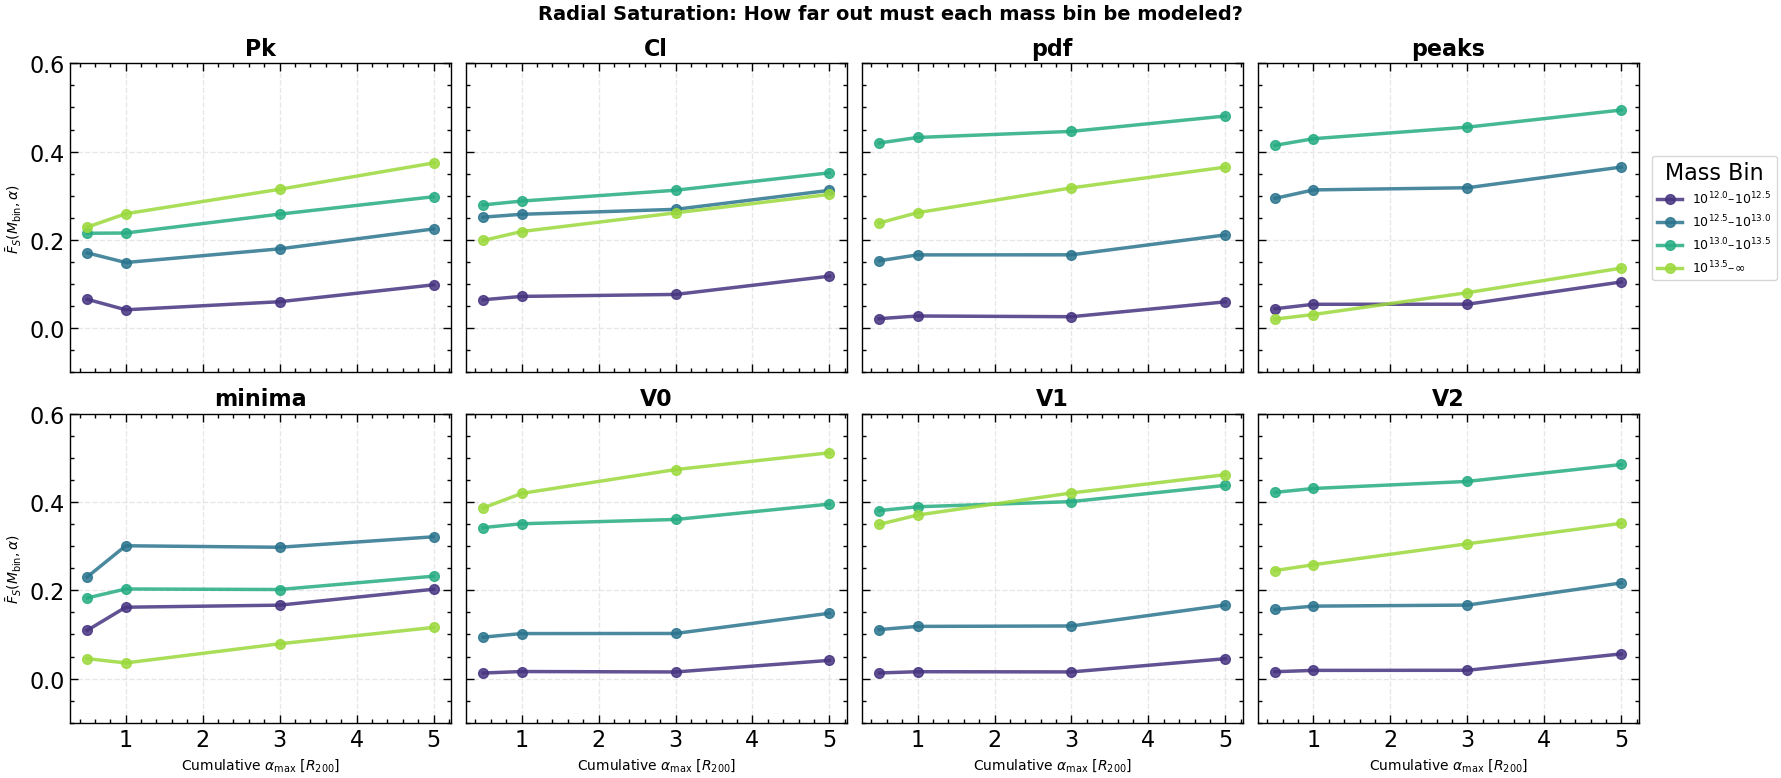

In [100]:
# Plot radial saturation curves
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(mass_bins_excl)))

for idx, (ax, stat_name) in enumerate(zip(axes.flatten(), STATISTICS)):
    row, col = idx // 4, idx % 4
    F_curves = F_curves_all[stat_name]
    
    for i, (mass_label, F_vs_alpha) in enumerate(F_curves.items()):
        ax.plot(alpha_cumulative, F_vs_alpha, 'o-', color=colors[i], 
               label=mass_label, linewidth=2.5, markersize=7, alpha=0.85)
    
    if row == 1:
        ax.set_xlabel(r'Cumulative $\alpha_{\rm max}$ [$R_{200}$]', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$\bar{F}_S(M_{\rm bin}, \alpha)$', fontsize=10)
    
    ax.set_title(f'{stat_name}', fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.axhline(0.9, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    
    if idx == 3:  # Add legend to first row, last column
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), 
                 frameon=True, fontsize=9, title='Mass Bin')

ax.set_ylim(-0.1, 0.6)
fig.suptitle('Radial Saturation: How far out must each mass bin be modeled?', 
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('figures/radial_saturation_curves.pdf', dpi=200, bbox_inches='tight')
plt.show()

## 12. Non-Additivity Analysis: Can we model mass/radius bins independently?

**Key Question:** Can baryonic effects be decomposed into independent contributions from each mass bin or radius shell?

**Why this matters:**
- If F is **additive**, we could build a modular BCM: model each mass bin separately, then sum
- **Non-additivity** means statistics are sensitive to *cross-correlations* between regions
- High non-additivity (~20-50%) means a simple sum-of-parts approach will have significant errors

**Two tests:**
1. **Mass-bin coupling** (left panel): Fix radius, compare F(all M) vs Σ F(M_i)
2. **Radius-shell coupling** (right panel): Fix mass, compare F(all α) vs Σ F(α_i)

$$\mathcal{N} = \frac{|F_{\rm cumulative} - \sum F_{\rm exclusive}|}{|F_{\rm cumulative}|}$$

In [102]:
def compute_nonadditivity_M_excl(F_all, stat_name, mass_bins, alpha_values):
    """
    Compute non-additivity when summing over mass bins at fixed radius.
    N^α-excl(α_i) = |F_cum(all M, α) - Σ F_excl(M_j, α)| / F_cum
    """
    nonadditivity = {}
    
    for alpha_max in alpha_values:
        # Cumulative model: all masses (M > 10^12), cumulative to alpha_max
        cum_model = get_model_name(12.0, 15.0, 0.0, alpha_max)
        F_cum = F_all.get(cum_model, {}).get(stat_name, np.nan)
        
        # Sum exclusive mass bins at this alpha
        F_sum = 0.0
        for M_lo, M_hi in mass_bins:
            excl_model = get_model_name(M_lo, M_hi, 0.0, alpha_max)
            F_excl = F_all.get(excl_model, {}).get(stat_name, 0.0)
            F_sum += F_excl if np.isfinite(F_excl) else 0.0
        
        if np.isfinite(F_cum) and F_cum != 0:
            nonadditivity[alpha_max] = np.abs(F_cum - F_sum) / np.abs(F_cum)
        else:
            nonadditivity[alpha_max] = np.nan
    
    return nonadditivity


def compute_nonadditivity_alpha_excl(F_all, stat_name, mass_thresholds, radius_shells):
    """
    Compute non-additivity when summing over radius shells at fixed mass.
    N^M-excl(M_min) = |F_cum(M_min, α_max) - Σ F_excl(M_min, α_i)| / F_cum
    """
    nonadditivity = {}
    
    # For each cumulative alpha (sum of shells up to that point)
    for M_lo in mass_thresholds:
        nonadditivity[M_lo] = {}
        
        for n_shells in range(1, len(radius_shells) + 1):
            # Cumulative alpha = outer edge of last shell included
            alpha_max = radius_shells[n_shells - 1][1]
            
            # Cumulative model
            cum_model = get_model_name(M_lo, 15.0, 0.0, alpha_max)
            F_cum = F_all.get(cum_model, {}).get(stat_name, np.nan)
            
            # Sum exclusive radius shells
            F_sum = 0.0
            for R_in, R_out in radius_shells[:n_shells]:
                excl_model = get_model_name(M_lo, 15.0, R_in, R_out)
                F_excl = F_all.get(excl_model, {}).get(stat_name, 0.0)
                F_sum += F_excl if np.isfinite(F_excl) else 0.0
            
            if np.isfinite(F_cum) and F_cum != 0:
                nonadditivity[M_lo][alpha_max] = np.abs(F_cum - F_sum) / np.abs(F_cum)
            else:
                nonadditivity[M_lo][alpha_max] = np.nan
    
    return nonadditivity

# Compute non-additivity for all statistics
nonadditivity_M_all = {}  # Mass-bin coupling
nonadditivity_alpha_all = {}  # Radius-shell coupling

for stat_name in STATISTICS:
    nonadditivity_M_all[stat_name] = compute_nonadditivity_M_excl(
        F_all, stat_name, mass_bins_excl, alpha_cumulative
    )
    nonadditivity_alpha_all[stat_name] = compute_nonadditivity_alpha_excl(
        F_all, stat_name, mass_thresholds_cum, radius_shells_excl
    )

print("Non-additivity computed for all statistics")

Non-additivity computed for all statistics


In [109]:
# Detailed breakdown: Show actual F values (cumulative vs sum of exclusive)
# This makes the non-additivity more intuitive

def compute_additivity_breakdown(F_all, statistics, mass_bins_excl, radius_shells_excl):
    """
    Compute detailed breakdown showing F_cum vs Σ F_excl for each statistic.
    Returns actual values, not just the difference.
    """
    results = {}
    
    for stat_name in statistics:
        # For the full model (all M, all α)
        full_model = get_model_name(12.0, 15.0, 0.0, 5.0)
        F_cum = F_all.get(full_model, {}).get(stat_name, np.nan)
        
        # Sum of exclusive mass bins (cumulative in α)
        F_sum_M = 0.0
        F_by_M = []
        for M_lo, M_hi in mass_bins_excl:
            model = get_model_name(M_lo, M_hi, 0.0, 5.0)
            F_val = F_all.get(model, {}).get(stat_name, 0.0)
            F_val = F_val if np.isfinite(F_val) else 0.0
            F_sum_M += F_val
            F_by_M.append((f"M={M_lo}-{M_hi}", F_val))
        
        # Sum of exclusive radius shells (cumulative in M)
        F_sum_alpha = 0.0
        F_by_alpha = []
        for R_in, R_out in radius_shells_excl:
            model = get_model_name(12.0, 15.0, R_in, R_out)
            F_val = F_all.get(model, {}).get(stat_name, 0.0)
            F_val = F_val if np.isfinite(F_val) else 0.0
            F_sum_alpha += F_val
            F_by_alpha.append((f"α={R_in}-{R_out}", F_val))
        
        results[stat_name] = {
            'F_cum': F_cum,
            'F_sum_M': F_sum_M,
            'F_by_M': F_by_M,
            'F_sum_alpha': F_sum_alpha,
            'F_by_alpha': F_by_alpha,
            'nonadd_M': np.abs(F_cum - F_sum_M) / np.abs(F_cum) if F_cum != 0 else np.nan,
            'nonadd_alpha': np.abs(F_cum - F_sum_alpha) / np.abs(F_cum) if F_cum != 0 else np.nan,
        }
    
    return results

# Compute breakdown
breakdown = compute_additivity_breakdown(F_all, STATISTICS, mass_bins_excl, radius_shells_excl)

# Print detailed table
print("=" * 90)
print("NON-ADDITIVITY BREAKDOWN: F_cumulative vs Σ F_exclusive")
print("=" * 90)
print(f"\n{'Statistic':<10} {'F_cum':>8} {'Σ F(M_i)':>10} {'Error %':>10} │ {'Σ F(α_i)':>10} {'Error %':>10}")
print("-" * 90)
for stat in STATISTICS:
    b = breakdown[stat]
    print(f"{stat:<10} {b['F_cum']:8.3f} {b['F_sum_M']:10.3f} {b['nonadd_M']*100:9.1f}% │ "
          f"{b['F_sum_alpha']:10.3f} {b['nonadd_alpha']*100:9.1f}%")

print("\n" + "=" * 90)
print("INTERPRETATION:")
print("-" * 90)
print("• Low error (<10%):  Effects are approximately separable (Pk, peaks)")
print("• High error (>20%): Cross-correlations between bins matter (V0, Cl, minima)")
print("• This means: simple 'add up the parts' BCM will fail for some statistics!")
print("=" * 90)

NON-ADDITIVITY BREAKDOWN: F_cumulative vs Σ F_exclusive

Statistic     F_cum   Σ F(M_i)    Error % │   Σ F(α_i)    Error %
------------------------------------------------------------------------------------------
Pk            0.904      0.995      10.1% │      1.053      16.4%
Cl            0.923      1.085      17.7% │      1.154      25.1%
pdf           0.985      1.117      13.4% │      1.210      22.9%
peaks         0.995      1.100      10.5% │      1.263      26.9%
minima        0.693      0.872      25.8% │      0.918      32.4%
V0            0.993      1.096      10.4% │      1.188      19.7%
V1            0.992      1.112      12.1% │      1.209      21.9%
V2            0.984      1.110      12.8% │      1.219      23.9%

INTERPRETATION:
------------------------------------------------------------------------------------------
• Low error (<10%):  Effects are approximately separable (Pk, peaks)
• High error (>20%): Cross-correlations between bins matter (V0, Cl, minima)
• Th

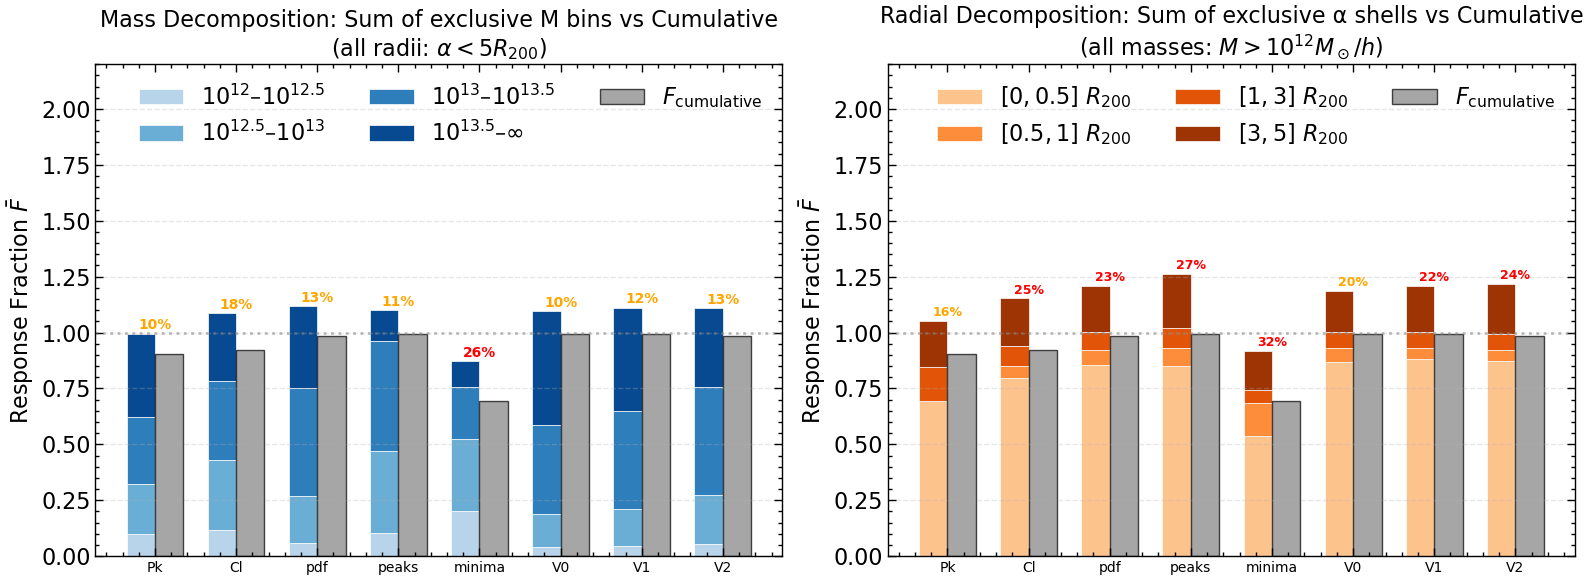


KEY FINDING: Non-linearity warning
The stacked bars (left) should equal the gray bars (right) if effects are additive.
Red percentages show the error from assuming additivity.

Statistics with HIGH non-additivity (>20%):
  • Cl: 18% (mass), 25% (radius)
  • pdf: 13% (mass), 23% (radius)
  • peaks: 11% (mass), 27% (radius)
  • minima: 26% (mass), 32% (radius)
  • V1: 12% (mass), 22% (radius)
  • V2: 13% (mass), 24% (radius)


In [110]:
# Clearer visualization: Stacked bar showing what you GET vs what you EXPECT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color scheme for mass bins and radius shells
mass_colors = plt.cm.Blues(np.linspace(0.3, 0.9, 4))
radius_colors = plt.cm.Oranges(np.linspace(0.3, 0.9, 4))

# ============ Panel 1: Mass decomposition ============
ax = axes[0]
x = np.arange(len(STATISTICS))
width = 0.35

# Stacked bars for Σ F(M_i) - each mass bin's contribution
bottoms = np.zeros(len(STATISTICS))
mass_bin_labels = [r'$10^{12}$–$10^{12.5}$', r'$10^{12.5}$–$10^{13}$', 
                   r'$10^{13}$–$10^{13.5}$', r'$10^{13.5}$–$\infty$']

for i, (M_lo, M_hi) in enumerate(mass_bins_excl):
    heights = []
    for stat in STATISTICS:
        for label, val in breakdown[stat]['F_by_M']:
            if f"M={M_lo}" in label:
                heights.append(val)
                break
    ax.bar(x - width/2, heights, width, bottom=bottoms, color=mass_colors[i], 
           label=mass_bin_labels[i], edgecolor='white', linewidth=0.5)
    bottoms += heights

# F_cumulative as comparison
F_cum_vals = [breakdown[s]['F_cum'] for s in STATISTICS]
ax.bar(x + width/2, F_cum_vals, width, color='gray', alpha=0.7, 
       label=r'$F_{\rm cumulative}$', edgecolor='black', linewidth=1)

# Add non-additivity error annotation
for i, stat in enumerate(STATISTICS):
    err = breakdown[stat]['nonadd_M'] * 100
    y_pos = max(breakdown[stat]['F_sum_M'], breakdown[stat]['F_cum']) + 0.02
    if err > 5:  # Only show if meaningful
        ax.annotate(f'{err:.0f}%', (i, y_pos), ha='center', 
                   color='red' if err > 20 else 'orange', fontweight='bold')

ax.set_ylabel(r'Response Fraction $\bar{F}$',)
ax.set_xticks(x)
ax.set_xticklabels(STATISTICS, fontsize=10)
ax.set_title('Mass Decomposition: Sum of exclusive M bins vs Cumulative\n' + 
             r'(all radii: $\alpha < 5 R_{200}$)')
ax.legend(loc='upper right', ncol=3)
ax.set_ylim(0, 2.2)
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# ============ Panel 2: Radius decomposition ============
ax = axes[1]
bottoms = np.zeros(len(STATISTICS))
radius_shell_labels = [r'$[0, 0.5]$', r'$[0.5, 1]$', r'$[1, 3]$', r'$[3, 5]$']

for i, (R_in, R_out) in enumerate(radius_shells_excl):
    heights = []
    for stat in STATISTICS:
        for label, val in breakdown[stat]['F_by_alpha']:
            if f"α={R_in}" in label:
                heights.append(val)
                break
    ax.bar(x - width/2, heights, width, bottom=bottoms, color=radius_colors[i], 
           label=radius_shell_labels[i] + r' $R_{200}$', edgecolor='white', linewidth=0.5)
    bottoms += heights

# F_cumulative as comparison
ax.bar(x + width/2, F_cum_vals, width, color='gray', alpha=0.7, 
       label=r'$F_{\rm cumulative}$', edgecolor='black', linewidth=1)

# Add non-additivity error annotation
for i, stat in enumerate(STATISTICS):
    err = breakdown[stat]['nonadd_alpha'] * 100
    y_pos = max(breakdown[stat]['F_sum_alpha'], breakdown[stat]['F_cum']) + 0.02
    if err > 5:
        ax.annotate(f'{err:.0f}%', (i, y_pos), ha='center', fontsize=9,
                   color='red' if err > 20 else 'orange', fontweight='bold')

ax.set_ylabel(r'Response Fraction $\bar{F}$')
ax.set_xticks(x)
ax.set_xticklabels(STATISTICS, fontsize=10)
ax.set_title('Radial Decomposition: Sum of exclusive α shells vs Cumulative\n' + 
             r'(all masses: $M > 10^{12} M_\odot/h$)')
ax.legend(loc='upper right', ncol=3)
ax.set_ylim(0, 2.2)
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('figures/nonadditivity_breakdown.pdf', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("KEY FINDING: Non-linearity warning")
print("=" * 80)
print("The stacked bars (left) should equal the gray bars (right) if effects are additive.")
print("Red percentages show the error from assuming additivity.")
print("\nStatistics with HIGH non-additivity (>20%):")
for stat in STATISTICS:
    err_M = breakdown[stat]['nonadd_M'] * 100
    err_alpha = breakdown[stat]['nonadd_alpha'] * 100
    if err_M > 20 or err_alpha > 20:
        print(f"  • {stat}: {err_M:.0f}% (mass), {err_alpha:.0f}% (radius)")
print("=" * 80)

In [121]:
# Load halo statistics to understand the physical drivers of non-additivity
test_dir = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n2500TNG/analysis'
import h5py 

with h5py.File(test_dir + '/halo_statistics_snap096.h5', 'r') as f:
    print("Keys in HDF5 file:", list(f.keys()))
    
    # Load key quantities
    log_masses = f['log_masses'][:]           # log10(M_200c) for each halo
    f_baryon = f['f_baryon'][:]               # Baryon fraction at 6 radii
    f_gas = f['f_gas'][:]                     # Gas fraction at 6 radii
    f_stellar = f['f_stellar'][:]             # Stellar fraction at 6 radii
    ratio_total = f['ratio_total'][:]         # M_hydro / M_dmo at 6 radii
    ratio_dm = f['ratio_dm'][:]               # M_dm,hydro / M_dmo at 6 radii
    radii_hydro = f['radii_hydro'][:]         # R_200 for each halo
    
print(f"\nLoaded {len(log_masses)} halos from snap096")
print(f"Mass range: 10^{log_masses.min():.2f} - 10^{log_masses.max():.2f} Msun/h")
print(f"Radial bins likely correspond to fractions of R_200 (6 bins)")

# Check the radial sampling - what fractions of R_200 do the 6 bins represent?
# Typically: [0.1, 0.3, 0.5, 1.0, 2.0, 5.0] × R_200 or similar
print(f"\nBaryon fraction shape: {f_baryon.shape}")
print(f"  → {f_baryon.shape[0]} halos × {f_baryon.shape[1]} radial bins")

Keys in HDF5 file: ['f_baryon', 'f_gas', 'f_stellar', 'log_masses', 'm_dm_hydro', 'm_dmo', 'm_gas', 'm_stellar', 'm_total', 'positions_dmo', 'positions_hydro', 'radii_dmo', 'radii_hydro', 'ratio_dm', 'ratio_total']

Loaded 28375 halos from snap096
Mass range: 10^12.00 - 10^14.98 Msun/h
Radial bins likely correspond to fractions of R_200 (6 bins)

Baryon fraction shape: (28375, 6)
  → 28375 halos × 6 radial bins


## 14. Core Profiles: Stellar Mass, Baryon Fraction, and Response

**Correction**: The previous M² weighting discussion was oversimplified. When computing P(k) from the overdensity field δ = (ρ - ρ̄)/ρ̄ directly with Pylians, the weighting is more complex than simple halo model M² scaling.

However, the **cores of halos** (small radii) clearly dominate the response signal. Let's examine:
1. How stellar mass fraction varies with halo mass at different radii
2. How the baryon deficit (f_b < cosmic f_b) varies in cores vs outskirts
3. Whether there's a correlation between core properties and the response

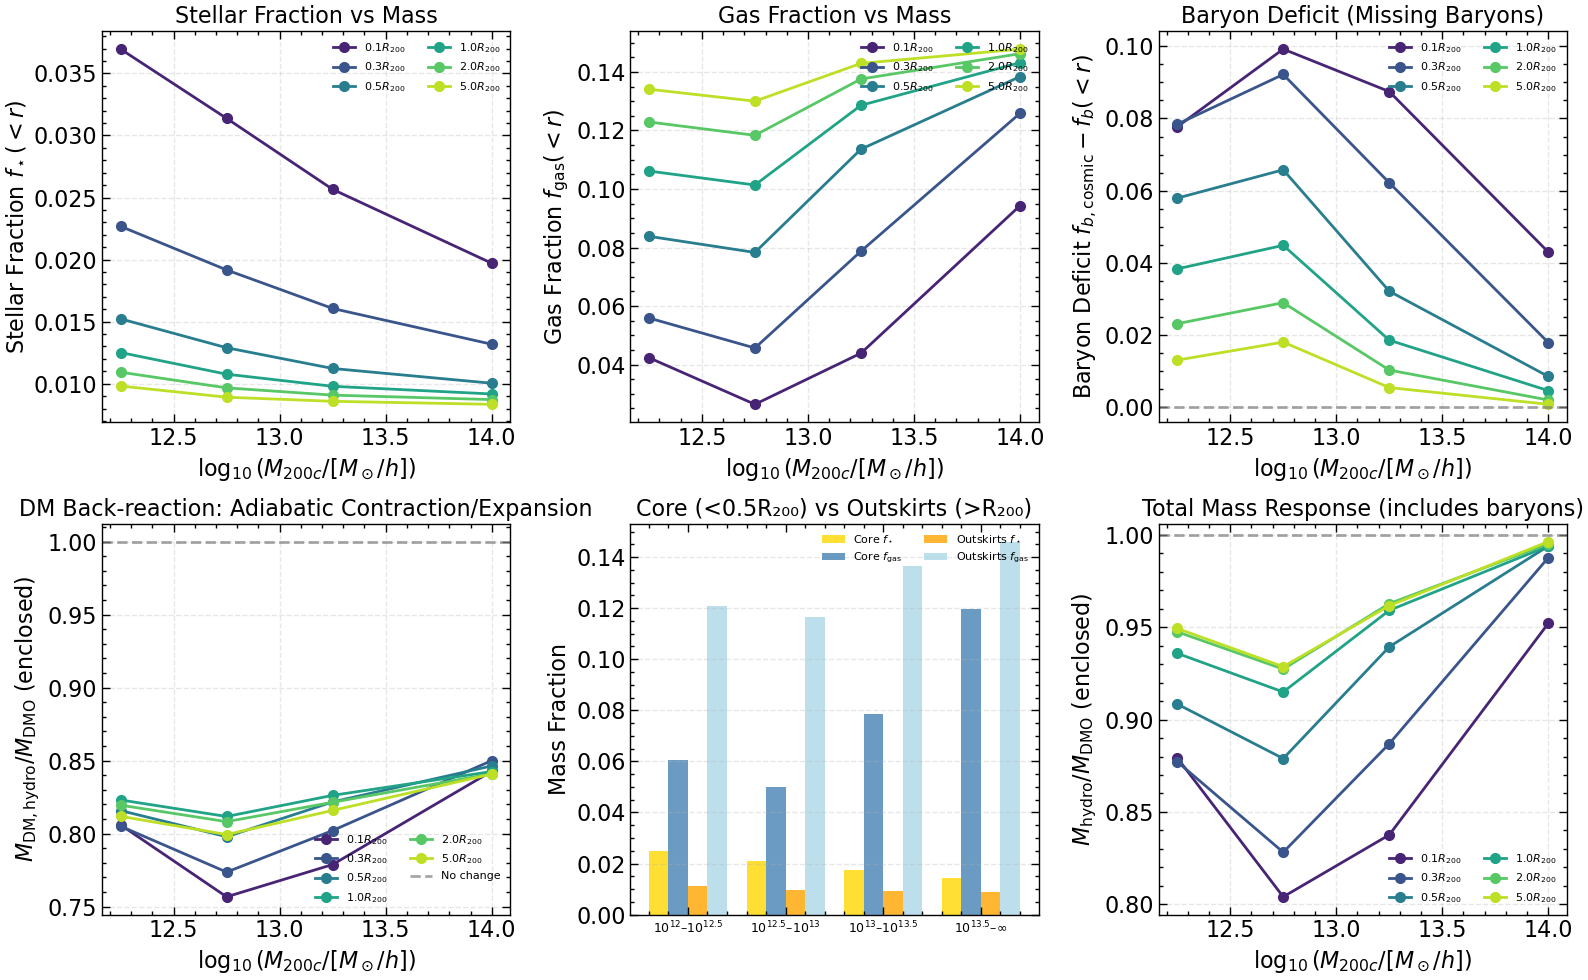

In [127]:
# Deep dive into core profiles across mass bins
# Focus on stellar fraction, gas fraction, and total baryon fraction

# Define cosmic baryon fraction (Planck 2018)
f_b_cosmic = 0.157  # Ω_b / Ω_m

# Radial labels - let's figure out what the 6 bins actually are
# Based on typical choices: [0.1, 0.3, 0.5, 1.0, 2.0, 5.0] × R_200
# But we should check the actual values used
radial_fracs = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]  # Assumed for now
radial_labels_detailed = [f'{r}' + r'$R_{200}$' for r in radial_fracs]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# =============================================================================
# Row 1: Fractions vs Mass at each radius
# =============================================================================

# Panel 1: Stellar fraction vs Mass (cores vs outskirts)
ax = axes[0, 0]
core_indices = [0, 1, 2]  # 0.1, 0.3, 0.5 R_200
outer_indices = [3, 4, 5]  # 1.0, 2.0, 5.0 R_200
colors_rad = plt.cm.viridis(np.linspace(0.1, 0.9, 6))

for rad_idx in range(6):
    f_stellar_vs_mass = [halo_stats_by_mass[mb]['mean_f_stellar'][rad_idx] for mb in mass_bins_analysis]
    ax.plot(mass_centers, f_stellar_vs_mass, 'o-', color=colors_rad[rad_idx], 
           label=radial_labels_detailed[rad_idx], linewidth=2, markersize=7)

ax.set_xlabel(r'$\log_{10}(M_{200c}/[M_\odot/h])$')
ax.set_ylabel(r'Stellar Fraction $f_\star(<r)$')
ax.set_title('Stellar Fraction vs Mass')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3, linestyle='--')

# Panel 2: Gas fraction vs Mass
ax = axes[0, 1]
for rad_idx in range(6):
    f_gas_vs_mass = [halo_stats_by_mass[mb]['mean_f_gas'][rad_idx] for mb in mass_bins_analysis]
    ax.plot(mass_centers, f_gas_vs_mass, 'o-', color=colors_rad[rad_idx], 
           label=radial_labels_detailed[rad_idx], linewidth=2, markersize=7)

ax.set_xlabel(r'$\log_{10}(M_{200c}/[M_\odot/h])$')
ax.set_ylabel(r'Gas Fraction $f_{\rm gas}(<r)$')
ax.set_title('Gas Fraction vs Mass')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3, linestyle='--')

# Panel 3: Baryon deficit (f_b,cosmic - f_b) vs Mass
ax = axes[0, 2]
for rad_idx in range(6):
    f_bar_vs_mass = [halo_stats_by_mass[mb]['mean_f_baryon'][rad_idx] for mb in mass_bins_analysis]
    baryon_deficit = f_b_cosmic - np.array(f_bar_vs_mass)
    ax.plot(mass_centers, baryon_deficit, 'o-', color=colors_rad[rad_idx], 
           label=radial_labels_detailed[rad_idx], linewidth=2, markersize=7)

ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel(r'$\log_{10}(M_{200c}/[M_\odot/h])$')
ax.set_ylabel(r'Baryon Deficit $f_{b,\rm cosmic} - f_b(<r)$')
ax.set_title('Baryon Deficit (Missing Baryons)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.3, linestyle='--')

# =============================================================================
# Row 2: Correlations with Response
# =============================================================================

# Panel 4: DM ratio (back-reaction) vs Mass at different radii
ax = axes[1, 0]
for rad_idx in range(6):
    ratio_dm_vs_mass = [halo_stats_by_mass[mb]['mean_ratio_dm'][rad_idx] for mb in mass_bins_analysis]
    ax.plot(mass_centers, ratio_dm_vs_mass, 'o-', color=colors_rad[rad_idx], 
           label=radial_labels_detailed[rad_idx], linewidth=2, markersize=7)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='No change')
ax.set_xlabel(r'$\log_{10}(M_{200c}/[M_\odot/h])$')
ax.set_ylabel(r'$M_{\rm DM,hydro}/M_{\rm DMO}$ (enclosed)')
ax.set_title('DM Back-reaction: Adiabatic Contraction/Expansion')
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(alpha=0.3, linestyle='--')

# Panel 5: Core vs Outskirts comparison
ax = axes[1, 1]

# Average over core (0.1-0.5 R200) and outskirts (1-5 R200)
core_f_stellar = np.mean([halo_stats_by_mass[mb]['mean_f_stellar'][:3] for mb in mass_bins_analysis], axis=1)
core_f_gas = np.mean([halo_stats_by_mass[mb]['mean_f_gas'][:3] for mb in mass_bins_analysis], axis=1)
outer_f_stellar = np.mean([halo_stats_by_mass[mb]['mean_f_stellar'][3:] for mb in mass_bins_analysis], axis=1)
outer_f_gas = np.mean([halo_stats_by_mass[mb]['mean_f_gas'][3:] for mb in mass_bins_analysis], axis=1)

x = np.arange(len(mass_bins_analysis))
width = 0.2

ax.bar(x - 1.5*width, core_f_stellar, width, label=r'Core $f_\star$', color='gold', alpha=0.8)
ax.bar(x - 0.5*width, core_f_gas, width, label=r'Core $f_{\rm gas}$', color='steelblue', alpha=0.8)
ax.bar(x + 0.5*width, outer_f_stellar, width, label=r'Outskirts $f_\star$', color='orange', alpha=0.8)
ax.bar(x + 1.5*width, outer_f_gas, width, label=r'Outskirts $f_{\rm gas}$', color='lightblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(mass_bin_labels, fontsize=9)
ax.set_ylabel('Mass Fraction')
ax.set_title('Core (<0.5R₂₀₀) vs Outskirts (>R₂₀₀)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Panel 6: Total response at each radius
ax = axes[1, 2]
for rad_idx in range(6):
    ratio_vs_mass = [halo_stats_by_mass[mb]['mean_ratio_total'][rad_idx] for mb in mass_bins_analysis]
    ax.plot(mass_centers, ratio_vs_mass, 'o-', color=colors_rad[rad_idx], 
           label=radial_labels_detailed[rad_idx], linewidth=2, markersize=7)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel(r'$\log_{10}(M_{200c}/[M_\odot/h])$')
ax.set_ylabel(r'$M_{\rm hydro}/M_{\rm DMO}$ (enclosed)')
ax.set_title('Total Mass Response (includes baryons)')
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('figures/core_profiles_analysis.pdf', dpi=200, bbox_inches='tight')
plt.show()

## 15. Comprehensive Baryon Fraction → Response Analysis

This section implements systematic analyses connecting the baryonic response $F_S(M, \alpha)$ to physical halo properties like baryon deficit $\Delta f_b$.

**Key Questions:**
1. **Correlation:** How well does $\Delta f_b$ predict $F_S$ across all tiles?
2. **Decomposition:** Is gas or stellar mass more important for each statistic?
3. **Closure vs Saturation:** Do statistics saturate where baryons close?
4. **Predictive Power:** Can $f_b$ profiles alone predict $F_S$?
5. **Radial Weighting:** Which radii matter most for each statistic?

**Data Structure:**
- Each snapshot maps to 2 redshift indices (reverse order): snap096 → z_idx 0,1; snap090 → z_idx 2,3; etc.
- Mass bins: [(12.0, 12.5), (12.5, 13.0), (13.0, 13.5), (13.5, 15.0)]
- Radius shells: [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)] in units of R₂₀₀

In [137]:
# ============================================================================
# SETUP: Load baryon profiles for all snapshots and define helper functions
# ============================================================================

import scipy.stats
from scipy.interpolate import interp1d

# Define snapshot-to-redshift mapping (each snapshot = 2 z_indices in reverse order)
SNAPSHOT_ORDER = [96, 90, 85, 80, 76, 71, 67, 63, 59, 56, 52, 49, 46, 43, 41, 38, 35, 33, 31, 29]
SNAPSHOT_TO_Z_IDX = {snap: [2*i, 2*i+1] for i, snap in enumerate(SNAPSHOT_ORDER)}

# Radial bins in the halo statistics files (fractions of R_200)
# These are the radii at which baryon fractions were measured
RADIAL_BINS_PROFILE = np.array([0.1, 0.3, 0.5, 1.0, 2.0, 5.0])

# Cosmic baryon fraction (Planck 2018)
f_b_cosmic = 0.157

# Define mass bins and radius shells for the analysis (exclusive bins)
mass_bins_excl = [(12.0, 12.5), (12.5, 13.0), (13.0, 13.5), (13.5, 15.0)]
radius_shells_excl = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]

# Cumulative radius values for saturation analysis
alpha_cumulative = [0.5, 1.0, 3.0, 5.0]

# Load baryon profiles from all snapshots
ANALYSIS_PATH = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n2500TNG/analysis'

def load_baryon_profiles_all_snapshots():
    """
    Load baryon fraction profiles for all mass bins from all snapshots.
    
    Returns
    -------
    profiles_by_snap : dict
        {snap_num: {(M_lo, M_hi): {'r': radii, 'f_b': baryon_frac, 
                                    'f_gas': gas_frac, 'f_star': stellar_frac,
                                    'n_halos': count}}}
    """
    profiles_by_snap = {}
    
    for snap in SNAPSHOT_ORDER:
        fpath = f'{ANALYSIS_PATH}/halo_statistics_snap{snap:03d}.h5'
        try:
            with h5py.File(fpath, 'r') as f:
                log_masses = f['log_masses'][:]
                f_baryon = f['f_baryon'][:]
                f_gas_data = f['f_gas'][:]
                f_stellar_data = f['f_stellar'][:]
            
            profiles_by_snap[snap] = {}
            
            for M_lo, M_hi in mass_bins_excl:
                mask = (log_masses >= M_lo) & (log_masses < M_hi)
                n_halos = np.sum(mask)
                
                if n_halos > 0:
                    profiles_by_snap[snap][(M_lo, M_hi)] = {
                        'r': RADIAL_BINS_PROFILE,
                        'f_b': np.mean(f_baryon[mask], axis=0),
                        'f_gas': np.mean(f_gas_data[mask], axis=0),
                        'f_star': np.mean(f_stellar_data[mask], axis=0),
                        'n_halos': n_halos
                    }
                    
        except Exception as e:
            print(f"Warning: Could not load snap{snap:03d}: {e}")
    
    return profiles_by_snap

# Load profiles
print("Loading baryon profiles from all snapshots...")
baryon_profiles_all = load_baryon_profiles_all_snapshots()
print(f"Loaded profiles for {len(baryon_profiles_all)} snapshots")

# Show example
snap_ex = 96
print(f"\nExample (snap{snap_ex}):")
for mb in mass_bins_excl:
    if mb in baryon_profiles_all[snap_ex]:
        p = baryon_profiles_all[snap_ex][mb]
        print(f"  {mb}: n_halos={p['n_halos']}, f_b(R200)={p['f_b'][3]:.4f}")

Loading baryon profiles from all snapshots...
Loaded profiles for 20 snapshots

Example (snap96):
  (12.0, 12.5): n_halos=18847, f_b(R200)=0.1187
  (12.5, 13.0): n_halos=6602, f_b(R200)=0.1121
  (13.0, 13.5): n_halos=2150, f_b(R200)=0.1384
  (13.5, 15.0): n_halos=776, f_b(R200)=0.1524


In [172]:
# ============================================================================
# ANALYSIS 1: Correlation between F_S and baryon deficit
# ============================================================================

def get_baryon_deficit_in_shell(profiles, M_lo, M_hi, r_in, r_out):
    """
    Compute average baryon deficit Δf_b = f_b_cosmic - f_b in a radial shell.
    """
    if (M_lo, M_hi) not in profiles:
        return np.nan
    
    r_profile = profiles[(M_lo, M_hi)]['r']
    f_b_profile = profiles[(M_lo, M_hi)]['f_b']
    
    # Find radial bins within the shell
    mask = (r_profile >= r_in) & (r_profile <= r_out)
    if np.sum(mask) > 0:
        f_b_shell = np.mean(f_b_profile[mask])
        return f_b_cosmic - f_b_shell
    
    # If no exact match, interpolate
    try:
        f_interp = interp1d(r_profile, f_b_profile, kind='linear', 
                           bounds_error=False, fill_value='extrapolate')
        r_mid = (r_in + r_out) / 2
        f_b_mid = f_interp(r_mid)
        return f_b_cosmic - f_b_mid
    except:
        return np.nan


def analyze_F_vs_baryon_deficit(all_results, baryon_profiles, statistics, 
                                 mass_bins, radius_bins, z_idx, snap=96):
    """
    Compute correlation between F_S(M,α) and Δf_b(M,α) across tiles.
    """
    correlations = {}
    
    for stat_name in statistics:
        Delta_fb_all = []
        F_all_tiles = []
        tile_labels = []
        weights = []
        
        for (M_lo, M_hi) in mass_bins:
            for (r_in, r_out) in radius_bins:
                # Get baryon deficit
                Delta_fb = get_baryon_deficit_in_shell(
                    baryon_profiles, M_lo, M_hi, r_in, r_out)
                
                if np.isnan(Delta_fb):
                    continue
                
                # Get F value for this exclusive tile
                model_name = get_model_name(M_lo, M_hi, r_in, r_out)
                
                # Use correct z_idx based on statistic type
                # Pk uses snapshot index (0-19), WL stats use kappa index (0-39)
                if stat_name == 'Pk':
                    # Map snapshot to Pk z_idx (snap096 = idx 0)
                    stat_z_idx = SNAPSHOT_ORDER.index(snap) if snap in SNAPSHOT_ORDER else 0
                else:
                    stat_z_idx = z_idx
                
                F_val = get_F_value(all_results[stat_name], model_name, stat_z_idx)
                
                if np.isfinite(F_val):
                    Delta_fb_all.append(Delta_fb)
                    F_all_tiles.append(F_val)
                    tile_labels.append(f'M{M_lo:.0f}-{M_hi:.0f}_R{r_in:.0f}-{r_out:.0f}')
                    
                    # Weight by halo count
                    if (M_lo, M_hi) in baryon_profiles:
                        weights.append(baryon_profiles[(M_lo, M_hi)]['n_halos'])
                    else:
                        weights.append(1)
        
        Delta_fb_all = np.array(Delta_fb_all)
        F_all_tiles = np.array(F_all_tiles)
        weights = np.array(weights)
        
        if len(Delta_fb_all) < 3:
            correlations[stat_name] = {
                'r': np.nan, 'p': np.nan, 
                'scatter_data': (Delta_fb_all, F_all_tiles),
                'weights': weights, 'tile_labels': tile_labels
            }
            continue
        
        # Pearson correlation
        r_pearson, p_value = scipy.stats.pearsonr(Delta_fb_all, F_all_tiles)
        
        correlations[stat_name] = {
            'r': r_pearson,
            'p': p_value,
            'scatter_data': (Delta_fb_all, F_all_tiles),
            'weights': weights,
            'tile_labels': tile_labels
        }
    
    return correlations


# Run Analysis 1
print("=" * 80)
print("ANALYSIS 1: Correlation between F and Baryon Deficit")
print("=" * 80)

# Use snap096 profiles (z~0.04, first snapshot)
snap_for_analysis = 96
profiles_snap96 = baryon_profiles_all[snap_for_analysis]

correlations_F_fb = analyze_F_vs_baryon_deficit(
    all_results, profiles_snap96, STATISTICS,
    mass_bins_excl, radius_shells_excl, 
    z_idx=Z_IDX, snap=snap_for_analysis
)

print("\nCorrelation r(F, Δf_b) by statistic:")
print("-" * 50)
for stat in STATISTICS:
    r = correlations_F_fb[stat]['r']
    p = correlations_F_fb[stat]['p']
    n = len(correlations_F_fb[stat]['scatter_data'][0])
    print(f"  {stat:>8}: r = {r:+.3f}, p = {p:.2e}, n = {n} tiles")

ANALYSIS 1: Correlation between F and Baryon Deficit

Correlation r(F, Δf_b) by statistic:
--------------------------------------------------
        Pk: r = +0.248, p = 3.54e-01, n = 16 tiles
        Cl: r = +0.459, p = 7.36e-02, n = 16 tiles
       pdf: r = +0.281, p = 2.91e-01, n = 16 tiles
     peaks: r = +0.507, p = 4.48e-02, n = 16 tiles
    minima: r = +0.719, p = 1.70e-03, n = 16 tiles
        V0: r = +0.119, p = 6.61e-01, n = 16 tiles
        V1: r = +0.164, p = 5.44e-01, n = 16 tiles
        V2: r = +0.272, p = 3.08e-01, n = 16 tiles


In [173]:
# ============================================================================
# ANALYSIS 1 (REVISED): Δf_b and F for EXCLUSIVE 4×4 = 16 tiles only
# ============================================================================

# Use only the exclusive (non-overlapping) bins
# mass_bins_excl = [(12.0, 12.5), (12.5, 13.0), (13.0, 13.5), (13.5, 15.0)]
# radius_shells_excl = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]

print("Using EXCLUSIVE tiles only:")
print(f"  Mass bins: {mass_bins_excl}")
print(f"  Radius shells: {radius_shells_excl}")
print(f"  Total: {len(mass_bins_excl)} × {len(radius_shells_excl)} = {len(mass_bins_excl)*len(radius_shells_excl)} tiles")

# Build Δf_b matrix for exclusive 4×4 tiles
def build_baryon_deficit_matrix_excl(baryon_profiles, mass_bins, radius_bins):
    """
    Build Δf_b(M, α) matrix for exclusive tiles.
    Δf_b = f_b^cosmic - f_b(M, α)
    """
    n_mass = len(mass_bins)
    n_rad = len(radius_bins)
    Delta_fb_matrix = np.full((n_mass, n_rad), np.nan)
    
    for i, (M_lo, M_hi) in enumerate(mass_bins):
        for j, (r_in, r_out) in enumerate(radius_bins):
            Delta_fb = get_baryon_deficit_in_shell(baryon_profiles, M_lo, M_hi, r_in, r_out)
            Delta_fb_matrix[i, j] = Delta_fb
    
    return Delta_fb_matrix

# Build the Δf_b matrix (4×4)
Delta_fb_matrix_excl = build_baryon_deficit_matrix_excl(
    profiles_snap96, mass_bins_excl, radius_shells_excl)

print(f"\nΔf_b matrix (baryon deficit) - EXCLUSIVE tiles:")
print(f"  Shape: {Delta_fb_matrix_excl.shape}")
print(f"  Range: [{np.nanmin(Delta_fb_matrix_excl):.4f}, {np.nanmax(Delta_fb_matrix_excl):.4f}]")

# Build F matrix for Pk (4×4)
F_matrix_Pk_excl = np.full((len(mass_bins_excl), len(radius_shells_excl)), np.nan)
for i, (M_lo, M_hi) in enumerate(mass_bins_excl):
    for j, (R_in, R_out) in enumerate(radius_shells_excl):
        model_name = get_model_name(M_lo, M_hi, R_in, R_out)
        if model_name in F_all:
            F_matrix_Pk_excl[i, j] = F_all[model_name].get('Pk', np.nan)

print(f"\nF(Pk) matrix - EXCLUSIVE tiles:")
print(f"  Range: [{np.nanmin(F_matrix_Pk_excl):.4f}, {np.nanmax(F_matrix_Pk_excl):.4f}]")

Using EXCLUSIVE tiles only:
  Mass bins: [(12.0, 12.5), (12.5, 13.0), (13.0, 13.5), (13.5, 15.0)]
  Radius shells: [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
  Total: 4 × 4 = 16 tiles

Δf_b matrix (baryon deficit) - EXCLUSIVE tiles:
  Shape: (4, 4)
  Range: [0.0008, 0.0857]

F(Pk) matrix - EXCLUSIVE tiles:
  Range: [-0.0200, 0.2290]


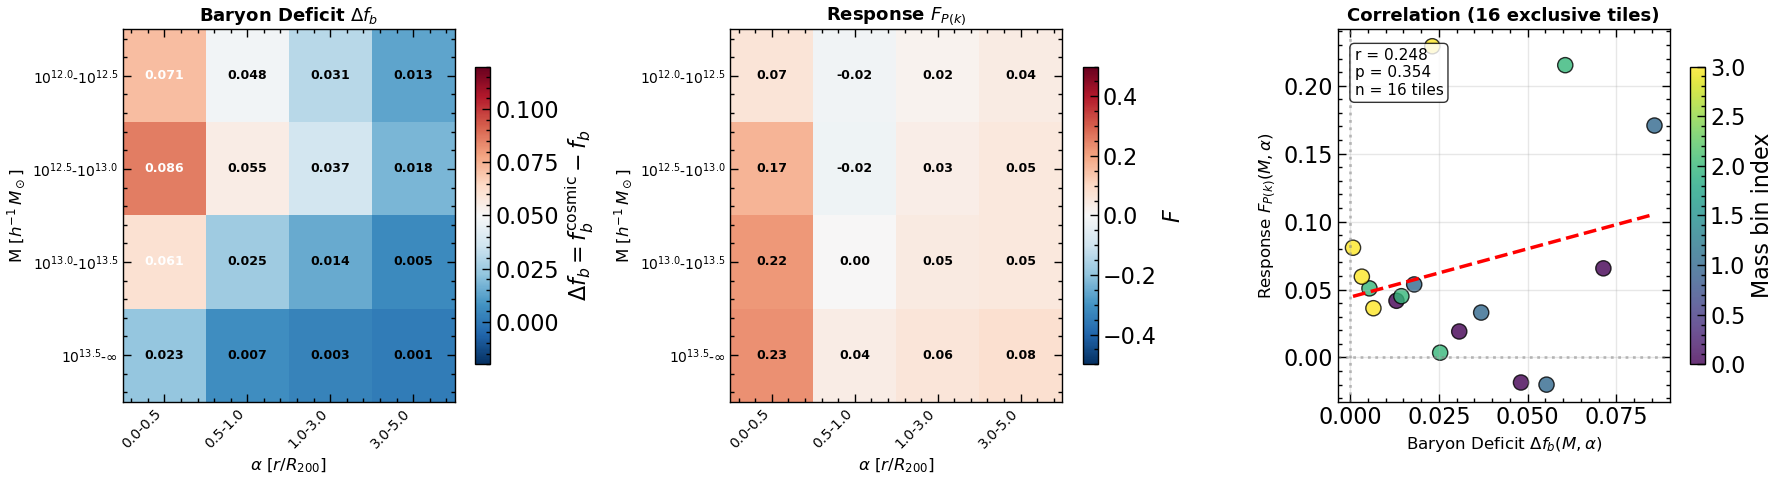


✓ Saved: figures/analysis1_Dfb_F_heatmaps_exclusive.pdf


In [174]:
# Plot side-by-side: Δf_b matrix and F matrix for EXCLUSIVE 4×4 tiles

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Labels for exclusive bins
mass_labels_excl = [f"$10^{{{M_lo:.1f}}}$-$10^{{{M_hi:.1f}}}$" if M_hi < 15.0 
                    else f"$10^{{{M_lo:.1f}}}$-∞" 
                    for M_lo, M_hi in mass_bins_excl]
radius_labels_excl = [f"{R_in}-{R_out}" for R_in, R_out in radius_shells_excl]

# Panel 1: Δf_b heatmap
ax1 = axes[0]
im1 = ax1.imshow(Delta_fb_matrix_excl, cmap='RdBu_r', aspect='auto', origin='upper',
                 vmin=-0.02, vmax=0.12)
ax1.set_xticks(range(len(radius_shells_excl)))
ax1.set_yticks(range(len(mass_bins_excl)))
ax1.set_xticklabels(radius_labels_excl, rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(mass_labels_excl, fontsize=10)
ax1.set_xlabel(r'$\alpha$ [$r/R_{200}$]', fontsize=12)
ax1.set_ylabel(r'M [$h^{-1}\,M_\odot$]', fontsize=12)
ax1.set_title(r'Baryon Deficit $\Delta f_b$', fontsize=13, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar1.set_label(r'$\Delta f_b = f_b^{\rm cosmic} - f_b$')

# Add values to cells
for i in range(len(mass_bins_excl)):
    for j in range(len(radius_shells_excl)):
        val = Delta_fb_matrix_excl[i, j]
        if np.isfinite(val):
            color = 'white' if abs(val) > 0.06 else 'black'
            ax1.text(j, i, f'{val:.3f}', ha='center', va='center', 
                    fontsize=9, color=color, fontweight='bold')

# Panel 2: F(Pk) heatmap
ax2 = axes[1]
im2 = ax2.imshow(F_matrix_Pk_excl, cmap='RdBu_r', aspect='auto', origin='upper',
                 vmin=-0.5, vmax=0.5)
ax2.set_xticks(range(len(radius_shells_excl)))
ax2.set_yticks(range(len(mass_bins_excl)))
ax2.set_xticklabels(radius_labels_excl, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(mass_labels_excl, fontsize=10)
ax2.set_xlabel(r'$\alpha$ [$r/R_{200}$]', fontsize=12)
ax2.set_ylabel(r'M [$h^{-1}\,M_\odot$]', fontsize=12)
ax2.set_title(r'Response $F_{P(k)}$', fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
cbar2.set_label(r'$F$')

# Add values to cells
for i in range(len(mass_bins_excl)):
    for j in range(len(radius_shells_excl)):
        val = F_matrix_Pk_excl[i, j]
        if np.isfinite(val):
            color = 'white' if abs(val) > 0.25 else 'black'
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', 
                    fontsize=9, color=color, fontweight='bold')

# Panel 3: Scatter plot of F vs Δf_b across all 16 tiles
ax3 = axes[2]

# Flatten both matrices and get valid pairs
Delta_fb_flat = Delta_fb_matrix_excl.flatten()
F_flat = F_matrix_Pk_excl.flatten()
valid = np.isfinite(Delta_fb_flat) & np.isfinite(F_flat)

Delta_fb_valid = Delta_fb_flat[valid]
F_valid = F_flat[valid]

# Scatter plot with color by mass bin
colors_scatter = []
for i in range(len(mass_bins_excl)):
    for j in range(len(radius_shells_excl)):
        if np.isfinite(Delta_fb_matrix_excl[i, j]) and np.isfinite(F_matrix_Pk_excl[i, j]):
            colors_scatter.append(i)

sc = ax3.scatter(Delta_fb_valid, F_valid, alpha=0.8, s=120, c=colors_scatter,
                cmap='viridis', edgecolors='k', linewidth=1)
plt.colorbar(sc, ax=ax3, label='Mass bin index', shrink=0.8)

# Fit line
if len(Delta_fb_valid) > 2:
    z = np.polyfit(Delta_fb_valid, F_valid, 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(Delta_fb_valid.min(), Delta_fb_valid.max(), 100)
    ax3.plot(x_line, p_fit(x_line), 'r--', linewidth=2.5)
    
    # Correlation
    r_val, p_val = scipy.stats.pearsonr(Delta_fb_valid, F_valid)
    ax3.text(0.05, 0.95, f'r = {r_val:.3f}\np = {p_val:.3f}\nn = {len(Delta_fb_valid)} tiles',
            transform=ax3.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel(r'Baryon Deficit $\Delta f_b(M, \alpha)$', fontsize=12)
ax3.set_ylabel(r'Response $F_{P(k)}(M, \alpha)$', fontsize=12)
ax3.set_title('Correlation (16 exclusive tiles)', fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax3.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/analysis1_Dfb_F_heatmaps_exclusive.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: figures/analysis1_Dfb_F_heatmaps_exclusive.pdf")

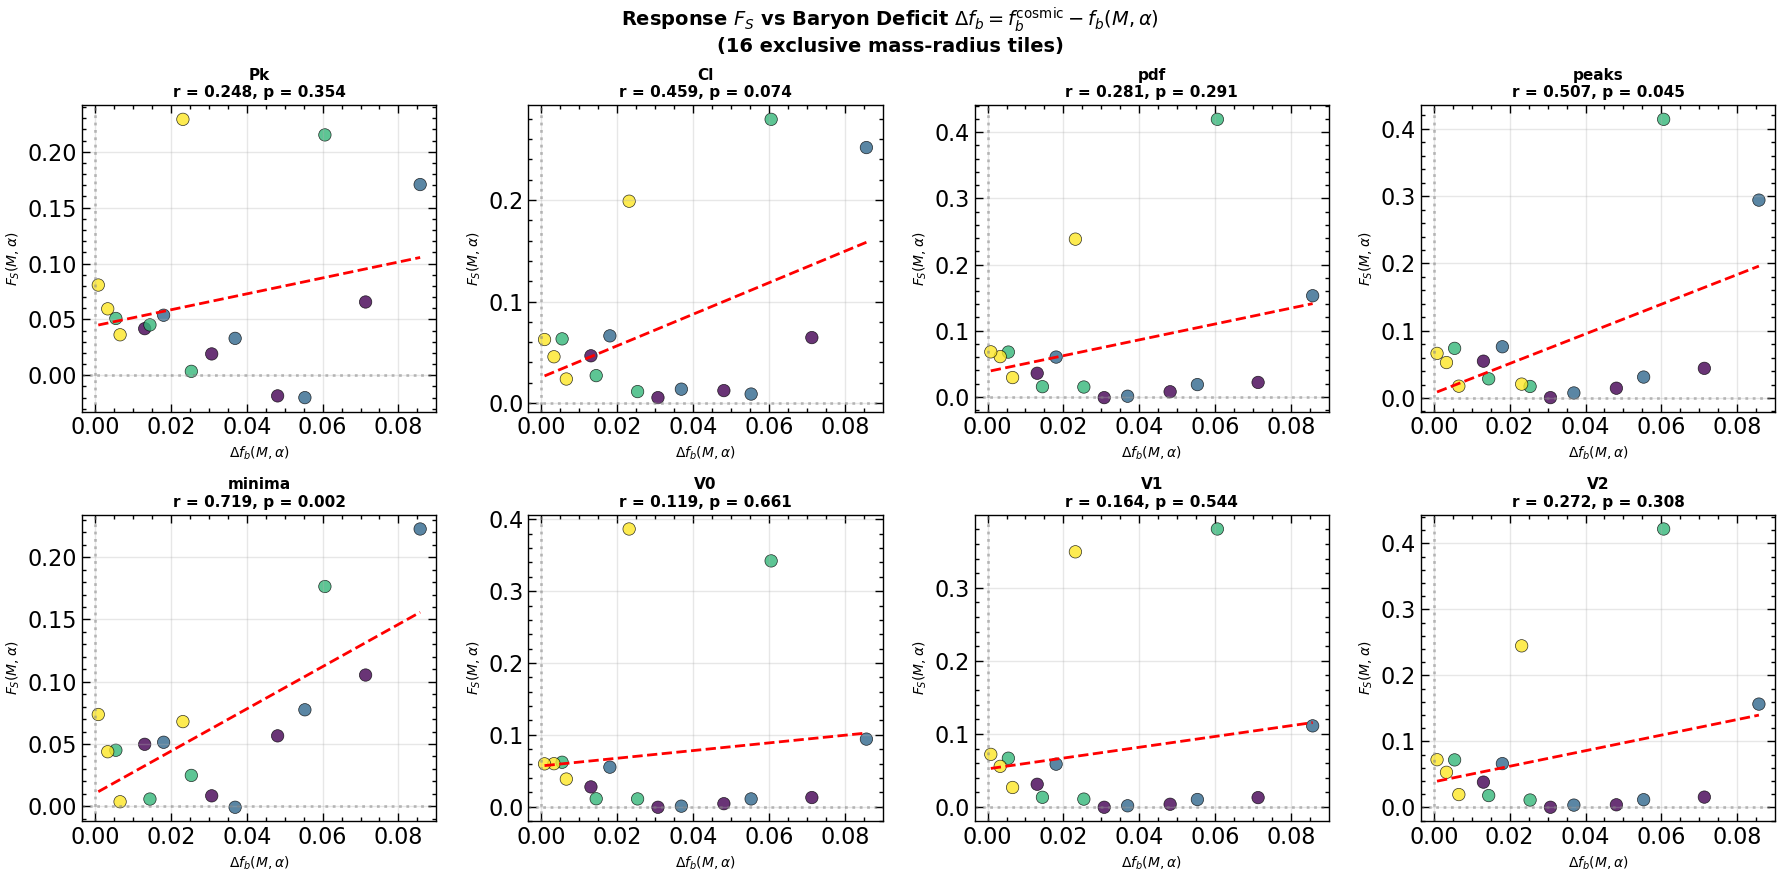


CORRELATION SUMMARY: F vs Δf_b (16 exclusive tiles)
 Statistic |        r |    p-value |      slope |  n tiles
----------------------------------------------------------------------
        Pk |   +0.248 |      0.354 |       0.71 |       16
        Cl |   +0.459 |      0.074 |       1.55 |       16
       pdf |   +0.281 |      0.291 |       1.20 |       16
     peaks |   +0.507 |      0.045 |       2.20 |       16
    minima |   +0.719 |      0.002 |       1.70 |       16
        V0 |   +0.119 |      0.661 |       0.53 |       16
        V1 |   +0.164 |      0.544 |       0.74 |       16
        V2 |   +0.272 |      0.308 |       1.18 |       16


In [175]:
# Correlation analysis for ALL 8 statistics using EXCLUSIVE 16 tiles

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

correlation_results_excl = {}

for idx, stat in enumerate(STATISTICS):
    ax = axes[idx]
    
    # Build F matrix for this statistic (4×4 exclusive)
    F_matrix_stat = np.full((len(mass_bins_excl), len(radius_shells_excl)), np.nan)
    for i, (M_lo, M_hi) in enumerate(mass_bins_excl):
        for j, (R_in, R_out) in enumerate(radius_shells_excl):
            model_name = get_model_name(M_lo, M_hi, R_in, R_out)
            if model_name in F_all:
                F_matrix_stat[i, j] = F_all[model_name].get(stat, np.nan)
    
    # Flatten and get valid pairs
    F_flat = F_matrix_stat.flatten()
    Delta_fb_flat = Delta_fb_matrix_excl.flatten()
    valid = np.isfinite(Delta_fb_flat) & np.isfinite(F_flat)
    
    Delta_fb_v = Delta_fb_flat[valid]
    F_v = F_flat[valid]
    
    # Color by mass bin
    colors_scatter = []
    for i in range(len(mass_bins_excl)):
        for j in range(len(radius_shells_excl)):
            if np.isfinite(Delta_fb_matrix_excl[i, j]) and np.isfinite(F_matrix_stat[i, j]):
                colors_scatter.append(i)
    
    # Scatter
    sc = ax.scatter(Delta_fb_v, F_v, alpha=0.8, s=80, c=colors_scatter,
                   cmap='viridis', edgecolors='k', linewidth=0.5)
    
    # Fit and correlation
    if len(Delta_fb_v) > 2:
        z = np.polyfit(Delta_fb_v, F_v, 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(Delta_fb_v.min(), Delta_fb_v.max(), 100)
        ax.plot(x_line, p_fit(x_line), 'r--', linewidth=2)
        
        r_val, p_val = scipy.stats.pearsonr(Delta_fb_v, F_v)
        correlation_results_excl[stat] = {'r': r_val, 'p': p_val, 'n': len(Delta_fb_v),
                                          'slope': z[0], 'intercept': z[1]}
        
        ax.set_title(f'{stat}\nr = {r_val:.3f}, p = {p_val:.3f}', fontsize=11, fontweight='bold')
    else:
        correlation_results_excl[stat] = {'r': np.nan, 'p': np.nan, 'n': 0}
        ax.set_title(f'{stat}\n(insufficient data)', fontsize=11)
    
    ax.set_xlabel(r'$\Delta f_b(M, \alpha)$', fontsize=10)
    ax.set_ylabel(r'$F_S(M, \alpha)$', fontsize=10)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)

fig.suptitle(r'Response $F_S$ vs Baryon Deficit $\Delta f_b = f_b^{\rm cosmic} - f_b(M,\alpha)$' + 
            '\n(16 exclusive mass-radius tiles)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/analysis1_F_vs_Dfb_all_stats_exclusive.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 70)
print("CORRELATION SUMMARY: F vs Δf_b (16 exclusive tiles)")
print("=" * 70)
print(f"{'Statistic':>10} | {'r':>8} | {'p-value':>10} | {'slope':>10} | {'n tiles':>8}")
print("-" * 70)
for stat in STATISTICS:
    res = correlation_results_excl[stat]
    if np.isfinite(res['r']):
        print(f"{stat:>10} | {res['r']:>+8.3f} | {res['p']:>10.3f} | {res['slope']:>10.2f} | {res['n']:>8}")
    else:
        print(f"{stat:>10} | {'N/A':>8} | {'N/A':>10} | {'N/A':>10} | {res['n']:>8}")

In [181]:
# ============================================================================
# Try more complex models for F vs Δf_b relationship
# ============================================================================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

def fit_multiple_models(Delta_fb, F, mass_indices=None, radius_indices=None):
    """
    Fit multiple models and compare their performance.
    
    Models:
    1. Linear: F = a*Δf_b + b
    2. Quadratic: F = a*Δf_b² + b*Δf_b + c
    3. Power law: F = a * Δf_b^b (for Δf_b > 0)
    4. With mass: F = a*Δf_b + b*M + c
    5. With radius: F = a*Δf_b + b*α + c
    6. Full: F = a*Δf_b + b*M + c*α + d*Δf_b*M + e
    """
    results = {}
    
    # 1. Linear
    X_lin = Delta_fb.reshape(-1, 1)
    model_lin = LinearRegression().fit(X_lin, F)
    F_pred_lin = model_lin.predict(X_lin)
    results['Linear'] = {
        'R2': r2_score(F, F_pred_lin),
        'params': {'slope': model_lin.coef_[0], 'intercept': model_lin.intercept_},
        'pred': F_pred_lin,
        'formula': r'$F = a \cdot \Delta f_b + b$'
    }
    
    # 2. Quadratic
    poly2 = PolynomialFeatures(degree=2, include_bias=False)
    X_quad = poly2.fit_transform(Delta_fb.reshape(-1, 1))
    model_quad = LinearRegression().fit(X_quad, F)
    F_pred_quad = model_quad.predict(X_quad)
    results['Quadratic'] = {
        'R2': r2_score(F, F_pred_quad),
        'params': {'coefs': model_quad.coef_, 'intercept': model_quad.intercept_},
        'pred': F_pred_quad,
        'formula': r'$F = a \cdot \Delta f_b^2 + b \cdot \Delta f_b + c$'
    }
    
    # 3. Power law (for positive Δf_b only)
    pos_mask = Delta_fb > 0.001
    if np.sum(pos_mask) > 3:
        log_dfb = np.log(Delta_fb[pos_mask])
        log_F = np.log(np.abs(F[pos_mask]) + 0.001)  # Add small offset to avoid log(0)
        try:
            slope_pow, intercept_pow = np.polyfit(log_dfb, log_F, 1)
            F_pred_pow = np.exp(intercept_pow) * (Delta_fb[pos_mask] ** slope_pow)
            results['Power Law'] = {
                'R2': r2_score(F[pos_mask], F_pred_pow),
                'params': {'exponent': slope_pow, 'amplitude': np.exp(intercept_pow)},
                'pred': F_pred_pow,
                'mask': pos_mask,
                'formula': r'$F = a \cdot \Delta f_b^b$'
            }
        except:
            pass
    
    # 4-6: Models with M and α (if indices provided)
    if mass_indices is not None and radius_indices is not None:
        M_arr = np.array(mass_indices, dtype=float)
        alpha_arr = np.array(radius_indices, dtype=float)
        
        # 4. With mass
        X_mass = np.column_stack([Delta_fb, M_arr])
        model_mass = LinearRegression().fit(X_mass, F)
        F_pred_mass = model_mass.predict(X_mass)
        results['Linear + Mass'] = {
            'R2': r2_score(F, F_pred_mass),
            'params': {'coef_dfb': model_mass.coef_[0], 'coef_M': model_mass.coef_[1], 
                      'intercept': model_mass.intercept_},
            'pred': F_pred_mass,
            'formula': r'$F = a \cdot \Delta f_b + b \cdot M_{\rm idx} + c$'
        }
        
        # 5. With radius
        X_rad = np.column_stack([Delta_fb, alpha_arr])
        model_rad = LinearRegression().fit(X_rad, F)
        F_pred_rad = model_rad.predict(X_rad)
        results['Linear + Radius'] = {
            'R2': r2_score(F, F_pred_rad),
            'params': {'coef_dfb': model_rad.coef_[0], 'coef_alpha': model_rad.coef_[1],
                      'intercept': model_rad.intercept_},
            'pred': F_pred_rad,
            'formula': r'$F = a \cdot \Delta f_b + b \cdot \alpha_{\rm idx} + c$'
        }
        
        # 6. Full model with interaction
        X_full = np.column_stack([Delta_fb, M_arr, alpha_arr, Delta_fb * M_arr])
        model_full = LinearRegression().fit(X_full, F)
        F_pred_full = model_full.predict(X_full)
        results['Full (M, α, interaction)'] = {
            'R2': r2_score(F, F_pred_full),
            'params': {'coefs': model_full.coef_, 'intercept': model_full.intercept_},
            'pred': F_pred_full,
            'formula': r'$F = a \cdot \Delta f_b + b \cdot M + c \cdot \alpha + d \cdot \Delta f_b \cdot M + e$'
        }
    
    return results

# Collect data with mass/radius indices
Delta_fb_list = []
F_list = []
mass_idx_list = []
radius_idx_list = []

for i, (M_lo, M_hi) in enumerate(mass_bins_excl):
    for j, (R_in, R_out) in enumerate(radius_shells_excl):
        dfb = Delta_fb_matrix_excl[i, j]
        f_val = F_matrix_Pk_excl[i, j]
        if np.isfinite(dfb) and np.isfinite(f_val):
            Delta_fb_list.append(dfb)
            F_list.append(f_val)
            mass_idx_list.append(i)
            radius_idx_list.append(j)

Delta_fb_arr = np.array(Delta_fb_list)
F_arr = np.array(F_list)
mass_idx_arr = np.array(mass_idx_list)
radius_idx_arr = np.array(radius_idx_list)

# Fit all models for P(k)
model_results_Pk = fit_multiple_models(Delta_fb_arr, F_arr, mass_idx_arr, radius_idx_arr)

print("=" * 80)
print("MODEL COMPARISON: F(Pk) vs Δf_b")
print("=" * 80)
print(f"\n{'Model':<30} | {'R²':>8} | Formula")
print("-" * 80)
for name, res in model_results_Pk.items():
    print(f"{name:<30} | {res['R2']:>8.4f} | {res['formula']}")

MODEL COMPARISON: F(Pk) vs Δf_b

Model                          |       R² | Formula
--------------------------------------------------------------------------------
Linear                         |   0.0616 | $F = a \cdot \Delta f_b + b$
Quadratic                      |   0.1523 | $F = a \cdot \Delta f_b^2 + b \cdot \Delta f_b + c$
Power Law                      |  -0.0479 | $F = a \cdot \Delta f_b^b$
Linear + Mass                  |   0.4165 | $F = a \cdot \Delta f_b + b \cdot M_{\rm idx} + c$
Linear + Radius                |   0.2338 | $F = a \cdot \Delta f_b + b \cdot \alpha_{\rm idx} + c$
Full (M, α, interaction)       |   0.5103 | $F = a \cdot \Delta f_b + b \cdot M + c \cdot \alpha + d \cdot \Delta f_b \cdot M + e$


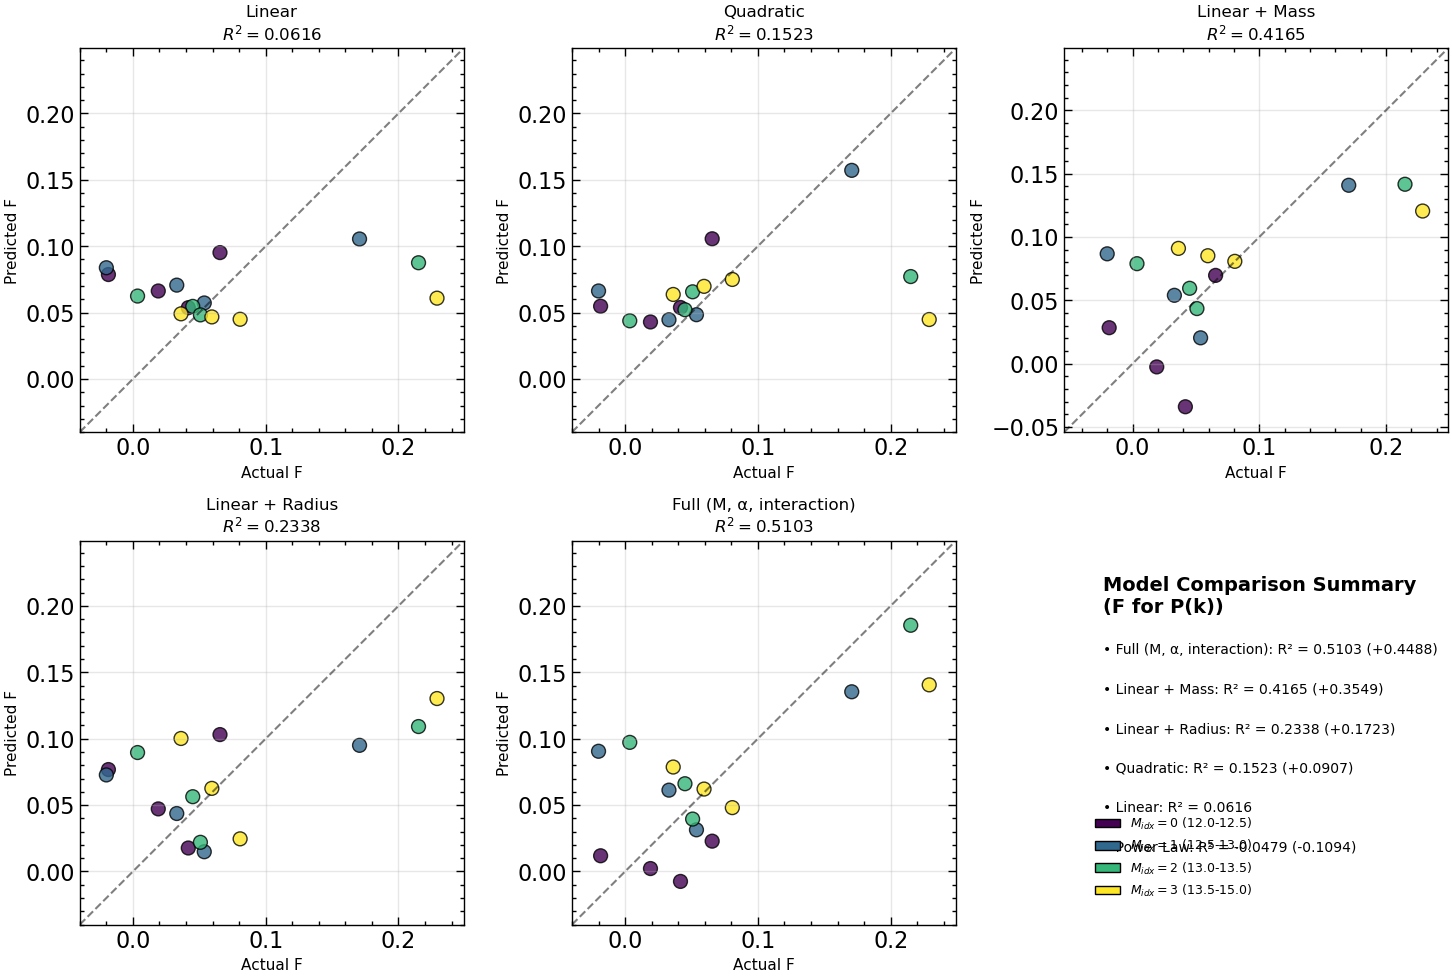


✓ Best model: Full (M, α, interaction) with R² = 0.5103
  Parameters: {'coefs': array([ 0.237121  ,  0.0185984 , -0.00550456,  1.05564141]), 'intercept': 0.005918837762368137}


In [182]:
# ============================================================================
# Visualize model comparison: predicted vs actual F
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Get the models that have full predictions (excluding Power Law with subset)
plot_models = ['Linear', 'Quadratic', 'Linear + Mass', 'Linear + Radius', 'Full (M, α, interaction)']

for ax_idx, model_name in enumerate(plot_models):
    ax = axes[ax_idx]
    res = model_results_Pk[model_name]
    F_pred = res['pred']
    R2 = res['R2']
    
    # Color by mass index
    scatter = ax.scatter(F_arr, F_pred, c=mass_idx_arr, cmap='viridis', 
                        s=100, edgecolor='k', alpha=0.8)
    
    # Perfect prediction line
    lims = [min(F_arr.min(), F_pred.min()) - 0.02, max(F_arr.max(), F_pred.max()) + 0.02]
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual F', fontsize=11)
    ax.set_ylabel('Predicted F', fontsize=11)
    ax.set_title(f'{model_name}\n$R^2 = {R2:.4f}$', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Use last axis for legend and summary
axes[5].axis('off')
axes[5].text(0.1, 0.9, 'Model Comparison Summary\n(F for P(k))', fontsize=14, fontweight='bold',
             transform=axes[5].transAxes, va='top')

# Sort by R²
sorted_models = sorted(model_results_Pk.items(), key=lambda x: x[1]['R2'], reverse=True)
y_pos = 0.7
for name, res in sorted_models:
    improvement = ''
    if name != 'Linear':
        base_R2 = model_results_Pk['Linear']['R2']
        delta_R2 = res['R2'] - base_R2
        if delta_R2 > 0:
            improvement = f' (+{delta_R2:.4f})'
        else:
            improvement = f' ({delta_R2:.4f})'
    axes[5].text(0.1, y_pos, f"• {name}: R² = {res['R2']:.4f}{improvement}",
                fontsize=10, transform=axes[5].transAxes)
    y_pos -= 0.1

# Add colorbar legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=plt.cm.viridis(i/3), edgecolor='k', 
                         label=f'$M_{{idx}}={i}$ ({mass_bins_excl[i][0]:.1f}-{mass_bins_excl[i][1]:.1f})') 
                  for i in range(4)]
axes[5].legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.05, 0.05), fontsize=9)

plt.tight_layout()
plt.savefig('figures/F_vs_dfb_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best model
best_model = sorted_models[0][0]
print(f"\n✓ Best model: {best_model} with R² = {sorted_models[0][1]['R2']:.4f}")
print(f"  Parameters: {sorted_models[0][1]['params']}")

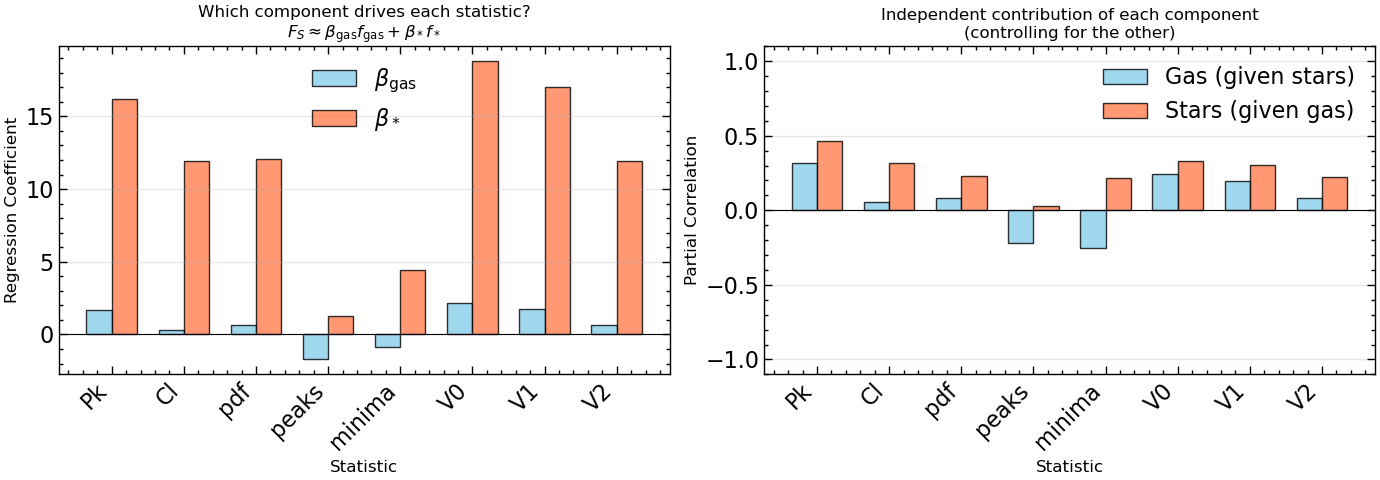


INTERPRETATION: Gas vs Stars

• β_gas > 0: Higher gas fraction → Higher F (response tracks gas)
• β_gas < 0: Higher gas fraction → Lower F (gas retention suppresses response)
• β_star > 0: Higher stellar fraction → Higher F (stellar feedback drives response)

Key insight: If |β_star| >> |β_gas|, stellar feedback dominates.
If partial_corr_gas ≈ 0 but partial_corr_star ≠ 0, gas is redundant given stars.



In [177]:
# Plot Analysis 2: Gas vs Stars Decomposition

def plot_gas_vs_stars_decomposition(decomposition, statistics=None, figsize=(14, 5)):
    """Plot regression coefficients and partial correlations."""
    if statistics is None:
        statistics = list(decomposition.keys())
    
    # Filter to valid statistics
    valid_stats = [s for s in statistics if np.isfinite(decomposition[s]['beta_gas'])]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    x = np.arange(len(valid_stats))
    width = 0.35
    
    # Panel 1: Regression coefficients
    beta_gas = [decomposition[s]['beta_gas'] for s in valid_stats]
    beta_star = [decomposition[s]['beta_star'] for s in valid_stats]
    
    bars1 = ax1.bar(x - width/2, beta_gas, width, label=r'$\beta_{\rm gas}$', 
                   color='skyblue', alpha=0.8, edgecolor='k')
    bars2 = ax1.bar(x + width/2, beta_star, width, label=r'$\beta_*$', 
                   color='coral', alpha=0.8, edgecolor='k')
    
    ax1.set_xlabel('Statistic', fontsize=12)
    ax1.set_ylabel('Regression Coefficient', fontsize=12)
    ax1.set_title('Which component drives each statistic?\n' + 
                 r'$F_S \approx \beta_{\rm gas} f_{\rm gas} + \beta_* f_*$', 
                 fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(valid_stats, rotation=45, ha='right')
    ax1.legend(loc='best')
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(0, color='k', linewidth=0.8)
    
    # Panel 2: Partial correlations
    partial_gas = [decomposition[s]['partial_corr_gas'] for s in valid_stats]
    partial_star = [decomposition[s]['partial_corr_star'] for s in valid_stats]
    
    bars3 = ax2.bar(x - width/2, partial_gas, width, label='Gas (given stars)', 
                   color='skyblue', alpha=0.8, edgecolor='k')
    bars4 = ax2.bar(x + width/2, partial_star, width, label='Stars (given gas)', 
                   color='coral', alpha=0.8, edgecolor='k')
    
    ax2.set_xlabel('Statistic', fontsize=12)
    ax2.set_ylabel('Partial Correlation', fontsize=12)
    ax2.set_title('Independent contribution of each component\n' + 
                 '(controlling for the other)', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(valid_stats, rotation=45, ha='right')
    ax2.legend(loc='best')
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim(-1.1, 1.1)
    ax2.axhline(0, color='k', linewidth=0.8)
    
    plt.tight_layout()
    return fig, (ax1, ax2)

fig2, _ = plot_gas_vs_stars_decomposition(decomposition, STATISTICS)
fig2.savefig('figures/analysis2_gas_vs_stars.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Interpretation
print("\n" + "=" * 80)
print("INTERPRETATION: Gas vs Stars")
print("=" * 80)
print("""
• β_gas > 0: Higher gas fraction → Higher F (response tracks gas)
• β_gas < 0: Higher gas fraction → Lower F (gas retention suppresses response)
• β_star > 0: Higher stellar fraction → Higher F (stellar feedback drives response)

Key insight: If |β_star| >> |β_gas|, stellar feedback dominates.
If partial_corr_gas ≈ 0 but partial_corr_star ≠ 0, gas is redundant given stars.
""")